# **1º Projeto de Aprendizagem Automática Não Supervisionada:**
## Pokémons
por: **Ilie Iftime - 112779, Inês Cruz - 123557, Sofia Quintino - 123554**

**_________________________________________________________________________________________________________________________________________________________________________________________________________**

## **Introdução**

Neste primeiro projeto de aprendizagem automática não supervisionada, iremos aplicar os conhecimentos adquiridos ao longo da unidade curricular.
Começaremos por analisar um conjunto de dados, recorrendo a bibliotecas como o pandas, numpy, sklearn, entre outras, para manipular e explorar os dados.
O objetivo é extrair informação relevante e preparar os dados para as fases seguintes.
De seguida, aplicaremos várias técnicas, nomeadamente _Principal Component Analysis_ (PCA), com o intuito de reduzir a dimensionalidade dos dados.
Esta redução permitirá a aplicação de algoritmos clustering, através dos quais procuraremos extrair insights valiosos sobre a distribuição e características dos Pokémons.

**O trabalho será dividido nas seguintes partes:**
1. Definição do problema
2. Caracterização do dataset
3. Data Wrangling
4. Análise dos Principal Component Analysis
5. Modelação com algoritmos de Clustering
6. Análise dos algortimos
7. Conclusão
8. Bibliografia

## **1. Definição do problema**

O problema abordado neste estudo insere-se no âmbito de _Unsupervised Machine Learning_, com foco inicial na redução de dimensionalidade dos dados dos Pokémon (através de PCA, t-SNE e UMAP), posteriormente a aplicação de Algoritmos de _Clustering_ para identificar agrupamentos naturais de Pokémon com características semelhantes. Para isso, foram consideradas variáveis como os tipos (primário e secundário), as diversas estatísticas de combate, a geração e a condição lendária. 
Assim, o objetivo central do trabalho consiste em definir grupos distintos, compreender as relações entre os seus atributos, detetar possíveis Pokémon atípicos (outliers) e apoiar uma categorização mais precisa e significativa dos Pokémon.

## **2. Caracterização do Dataset**

Pokémon é um jogo criado pela Nintendo, cujo objetivo é capturar criaturas chamadas Pokémon, treiná-las e utilizá-las em batalhas contra outros jogadores.

Este dataset contém informações sobre 800 Pokémon, incluindo o nome, os tipos de elemento primário e secundário (quando aplicável), bem como estatísticas como pontos de vida (HP), ataque, defesa, velocidade, defesa especial e ataque especial. Inclui ainda dados sobre a geração a que pertencem e se são ou não considerados lendários.

A análise destes atributos permite estudar a influência do desempenho dos Pokémon nas batalhas disputadas, além de explorar as relações entre diferentes características e compreender a importância de cada variável na distinção entre os diversos Pokémon.

Dataset: **https://www.kaggle.com/datasets/abcsds/pokemon**


In [10]:
import pandas as pd
from IPython.display import display

#Dados para a tabela
data = {
    "Atributo": ["Name", "Type 1", "Type 2", "Total", "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed", "Generation", "Legendary"],
    "Nome": ["nome", "tipo 1", "tipo 2", "total", "vida", "ataque", "defesa", "ataque especial", "defesa especial", "velocidade", "geração", "lendário"],
    "Tipo de Variável": ["string", "string", "string", "inteiro", "inteiro", "inteiro", "inteiro", "inteiro", "inteiro", "inteiro", "inteiro", "booleano"],
    "Descrição": [
        "Nome do Pokémon",
        "Tipo elemental principal",
        "Tipo elemental secundário (se existir)",
        "Soma total das estatísticas do Pokémon",
        "Quantidade de pontos de vida do Pokémon",
        "Capacidade de dano em ataques físicos",
        "Capacidade de defesa contra ataques físicos",
        "Capacidade de dano em ataques especiais",
        "Capacidade de defesa contra ataques especiais",
        "Velocidade do Pokémon",
        "Geração à qual o Pokémon pertence",
        "Indica se o Pokémon é lendário (True ou False)"
    ]
}

#Criar o DataFrame
df = pd.DataFrame(data)

#Exibir a tabela
print(df)

display(df)

      Atributo             Nome Tipo de Variável  \
0         Name             nome           string   
1       Type 1           tipo 1           string   
2       Type 2           tipo 2           string   
3        Total            total          inteiro   
4           HP             vida          inteiro   
5       Attack           ataque          inteiro   
6      Defense           defesa          inteiro   
7      Sp. Atk  ataque especial          inteiro   
8      Sp. Def  defesa especial          inteiro   
9        Speed       velocidade          inteiro   
10  Generation          geração          inteiro   
11   Legendary         lendário         booleano   

                                         Descrição  
0                                  Nome do Pokémon  
1                         Tipo elemental principal  
2           Tipo elemental secundário (se existir)  
3           Soma total das estatísticas do Pokémon  
4          Quantidade de pontos de vida do Pokémon  
5    

,Atributo,Nome,Tipo de Variável,Descrição
0,Name,nome,string,Nome do Pokémon
1,Type 1,tipo 1,string,Tipo elemental principal
2,Type 2,tipo 2,string,Tipo elemental secundário (se existir)
3,Total,total,inteiro,Soma total das estatísticas do Pokémon
4,HP,vida,inteiro,Quantidade de pontos de vida do Pokémon
5,Attack,ataque,inteiro,Capacidade de dano em ataques físicos
6,Defense,defesa,inteiro,Capacidade de defesa contra ataques físicos
7,Sp. Atk,ataque especial,inteiro,Capacidade de dano em ataques especiais
8,Sp. Def,defesa especial,inteiro,Capacidade de defesa contra ataques especiais
9,Speed,velocidade,inteiro,Velocidade do Pokémon


Verifica-se que o conjunto de dados é composto por variáveis qualitativas e quantitativas. As variáveis qualitativas nominais do tipo string são: “nome”, “tipo 1” e “tipo 2”, representando respetivamente o nome do Pokémon e os seus elementos primário e secundário. Existe ainda uma variável qualitativa nominal do tipo booleano — “lendário” — que indica se o Pokémon é considerado lendário (True ou False). As restantes variáveis são quantitativas contínuas e descrevem os atributos estatísticos dos Pokémon, tais como pontos de vida, ataque, defesa, velocidade, entre outros.

## **3. Data Wrangling**

Importar as bibliotecas necessárias.

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Importação e visualização do dataset, incluindo dimensões - linhas e colunas.

In [16]:
dataset = pd.read_csv('Pokemon.csv')
print("Tamanho do dataset(linhas, colunas): ", dataset.shape)
dataset.head()

Tamanho do dataset(linhas, colunas):  (800, 13)


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


Removemos a coluna `#` do dataset porque representava um índice redundante, automaticamente gerado pelo *Pandas*. A sua presença era desnecessária e poderia gerar ambiguidade durante a análise e manipulação dos dados.

In [18]:
dataset.drop(columns=["#"], inplace=True)
dataset.head()

,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


Para facilitar a leitura, os nomes das variáveis foram traduzidos para português.

In [20]:
dataset.rename(columns={
    "Name": "nome",
    "Type 1": "tipo 1",
    "Type 2": "tipo 2",
    "Total": "total",
    "HP": "vida",
    "Attack": "ataque",
    "Defense": "defesa",
    "Sp. Atk": "ataque especial",
    "Sp. Def": "defesa especial",
    "Speed": "velocidade",
    "Generation": "geração",
    "Legendary": "lendário"
}, inplace=True)
dataset.head()

,nome,tipo 1,tipo 2,total,vida,ataque,defesa,ataque especial,defesa especial,velocidade,geração,lendário
0,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


Neste passo, analisámos a quantidade de valores nulos no dataset, tanto no conjunto de dados completo quanto por coluna. 

In [22]:
total_nulos = dataset.isnull().sum().sum()
print("Total de nulos do dataset: ", total_nulos)
print()
nulos_por_coluna = dataset.isnull().sum()
print(f"Nulos por coluna:\n{nulos_por_coluna}")

Total de nulos do dataset:  386

Nulos por coluna:
nome                 0
tipo 1               0
tipo 2             386
total                0
vida                 0
ataque               0
defesa               0
ataque especial      0
defesa especial      0
velocidade           0
geração              0
lendário             0
dtype: int64


Verificámos que apenas a coluna `tipo 2` contém valores nulos, o que é esperado, pois nem todos os Pokémons possuem um segundo tipo.

Assim, os valores nulos na coluna `tipo 2` foram preenchidos com *"Inexistente"* dado que muitos pokémons não terem um elemento secundário. Após este ajuste, confirmámos que a coluna já não apresenta valores nulos, um procedimento essencial para assegurar a integridade dos dados.

In [24]:
dataset['tipo 2'] = dataset['tipo 2'].fillna('Inexistente')
print(dataset['tipo 2'].isnull().sum())

0


Nos passos seguintes, analisámos as categorias presentes em determinadas coluna.

Existem 18 tipos de elementos primários e secundários presentes no contexto deste dataset.

In [26]:
print(dataset['tipo 1'].unique())

['Grass' 'Fire' 'Water' 'Bug' 'Normal' 'Poison' 'Electric' 'Ground'
 'Fairy' 'Fighting' 'Psychic' 'Rock' 'Ghost' 'Ice' 'Dragon' 'Dark' 'Steel'
 'Flying']


Verificou-se a existência predominante de pokémons do tipo de água, normal e folha no tipo primário.

In [28]:
print(dataset["tipo 1"].value_counts())

tipo 1
Water       112
Normal       98
Grass        70
Bug          69
Psychic      57
Fire         52
Electric     44
Rock         44
Dragon       32
Ground       32
Ghost        32
Dark         31
Poison       28
Steel        27
Fighting     27
Ice          24
Fairy        17
Flying        4
Name: count, dtype: int64


Os elementos secundários coincidem com os primários, existindo quase metade do conjunto com a inexistência de um segundo elemento.

In [30]:
print(dataset['tipo 2'].unique())

['Poison' 'Inexistente' 'Flying' 'Dragon' 'Ground' 'Fairy' 'Grass'
 'Fighting' 'Psychic' 'Steel' 'Ice' 'Rock' 'Dark' 'Water' 'Electric'
 'Fire' 'Ghost' 'Bug' 'Normal']


In [31]:
print(dataset['geração'].unique())

[1 2 3 4 5 6]


In [32]:
print(dataset["geração"].value_counts())

geração
1    166
5    165
3    160
4    121
2    106
6     82
Name: count, dtype: int64


De notar que as gerações existentes vão da primeira á sexta, revelando maior número de entradas em gerações de número ímpar.

In [34]:
print(dataset['lendário'].unique())

[False  True]


In [35]:
#Número de lendários
dataset["lendário"].value_counts()

lendário
False    735
True      65
Name: count, dtype: int64

Existem cerca de 8,1% de pokémons lendários neste conjunto de dados, ou seja cerca de 1 em 11 é lendário.

## 4. **Aplicação e análise dos Principal Component Analysis (PCAs)**

Importar as bibliotecas necessárias

In [39]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import umap.umap_ as umap
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

Iremos preparar os dados para análise, transformando variáveis categóricas em numéricas e normalizando os atributos contínuos, de forma a facilitar a aplicação de algoritmos de machine learning.

In [41]:
#Criou-se uma cópia das variáveis para preservá-las e para evitar o warning
Y = dataset[['lendário', 'tipo 1', 'tipo 2']].copy()
#Alterou-se o tipo das três variáveis para *string*, já que os valores booleanos seriam desconsiderados na transformação com o `LabelEncoder`
Y = Y.astype(str)
#Aplicação do LabelEncoder, transformando cada coluna de Y em números inteiros
label_encoder = LabelEncoder()
for column in Y.columns:
    Y.loc[:, column] = label_encoder.fit_transform(Y[column])

#Visualização de Y após a transformação
print(Y.head())

#Remove as colunas categóricas e o nome dos Pokémon, mantendo apenas os atributos numéricos contínuos (como HP, ataque, defesa, etc.)
#Aplica o MinMaxScaler para normalizar os dados entre 0 e 1.
X = dataset.drop(['lendário', 'tipo 1', 'tipo 2', 'nome'], axis=1)  
scale = MinMaxScaler()
X_escalado = scale.fit_transform(X)

#Faz-se o merge da variável normalizada (X_escalado) com as colunas categóricas transformadas (Y) utilizando o encoder, criando o dataframe final Z
Z = pd.concat([Y, pd.DataFrame(X_escalado, columns=[f'col{i}' for i in range(X_escalado.shape[1])])], axis=1)

#Exibir resultado
print(Z)

  lendário tipo 1 tipo 2
0        0      9     14
1        0      9     14
2        0      9     14
3        0      9     14
4        0      6     12
    lendário tipo 1 tipo 2      col0      col1      col2      col3      col4  \
0          0      9     14  0.230000  0.173228  0.237838  0.195556  0.298913   
1          0      9     14  0.375000  0.232283  0.308108  0.257778  0.380435   
2          0      9     14  0.575000  0.311024  0.416216  0.346667  0.489130   
3          0      9     14  0.741667  0.311024  0.513514  0.524444  0.608696   
4          0      6     12  0.215000  0.149606  0.254054  0.168889  0.271739   
..       ...    ...    ...       ...       ...       ...       ...       ...   
795        1     15      4  0.700000  0.192913  0.513514  0.644444  0.489130   
796        1     15      4  0.866667  0.192913  0.837838  0.466667  0.815217   
797        1     14      8  0.700000  0.311024  0.567568  0.244444  0.760870   
798        1     14      1  0.833333  0.311024  0.

Verifica-se a correcta aplicação do label encoder nas variáveis nominais bem como a normalização bem sucedida das variáveis quantitativas contínuas. 

#### 1. PCA

Aplicamos o PCA para reduzir a dimensionalidade dos dados, projetando-os em duas componentes principais (PC1 e PC2), o que facilita a visualização e análise dos agrupamentos.

In [45]:
#Aplicamos o PCA
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(Z)
principalDataframe = pd.DataFrame(data = principalComponents, columns = ['PC1', 'PC2'])
principalDataframe.head()

,PC1,PC2
0,0.689989,-3.480499
1,0.689766,-3.477705
2,0.689460,-3.473838
3,0.688897,-3.471586
4,3.555314,-1.291408


Calculamos a percentagem de variância explicada por cada componente principal (PC1 e PC2), permitindo avaliar o quanto da informação original foi preservada após a redução de dimensionalidade.

In [47]:
#Percentagem de variância explicada
percent_variance = np.round(pca.explained_variance_ratio_ * 100, decimals=2)

variancia_explicada = pd.DataFrame({
    'Componente Principal': ['PC1', 'PC2'],
    'Percentagem de Variância Explicada (%)': percent_variance
})

#Exibição da tabela
print(variancia_explicada)
pca.explained_variance_ratio_
print("Variância explicada por cada componente:", pca.explained_variance_ratio_)
print("Variância total explicada:", sum(pca.explained_variance_ratio_))

  Componente Principal  Percentagem de Variância Explicada (%)
0                  PC1                                   68.50
1                  PC2                                   30.72
Variância explicada por cada componente: [0.68499388 0.30721125]
Variância total explicada: 0.9922051317464591


Os dados reduzidos preservaram em 99% a integridade da informação.

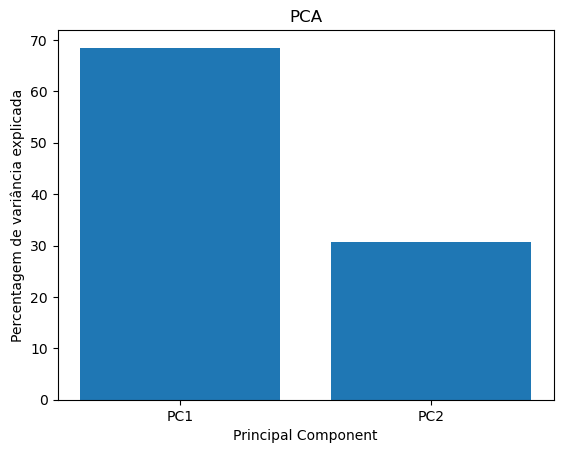

In [49]:
percent_variance = np.round(pca.explained_variance_ratio_* 100, decimals =2)
columns = ['PC1', 'PC2']
plt.bar(x=range(1,3), height=percent_variance, tick_label=columns)
plt.ylabel('Percentagem de variância explicada')
plt.xlabel('Principal Component')
plt.title('PCA')
plt.show()

Como esperado num processo eficaz de redução de dimensionalidade, a maior parte da informação original é preservada nas principais componentes — neste caso, as duas juntas conseguem representar cerca de 99% da variância presente nos dados originais (a PC1 retém cerca de 68% da variância total dos dados e a PC2 explica cerca de 31%). Isso indica que é possível visualizar e analisar os dados em apenas duas dimensões com uma perda mínima de informação, o que facilita aplicações como clustering.

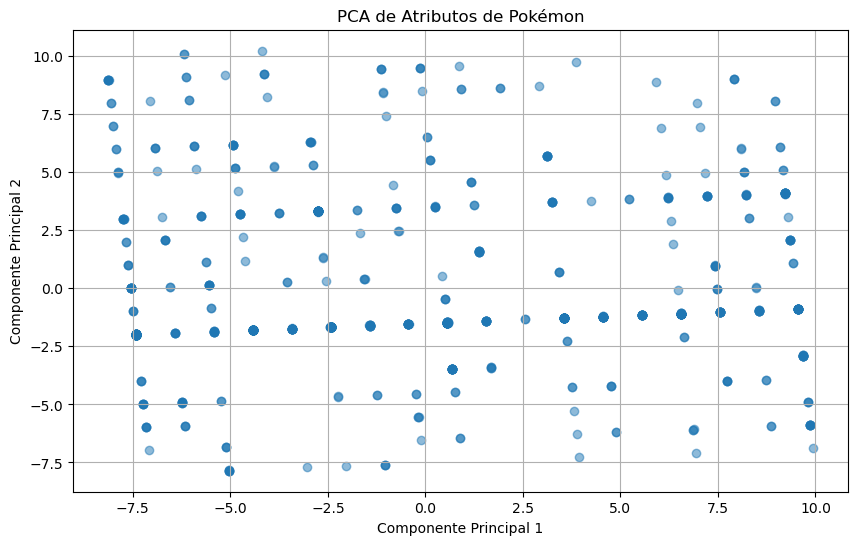

In [51]:
plt.figure(figsize=(10,6))
plt.scatter(principalDataframe['PC1'], principalDataframe['PC2'], alpha=0.5)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('PCA de Atributos de Pokémon')
plt.grid()
plt.show()

O gráfico de dispersão apresenta os dados reduzidos pelas duas componentes principais (PC1 e PC2) após a aplicação do PCA. Observa-se uma distribuição ampla e aparentemente aleatória dos pontos, sem padrões visuais bem definidos ou agrupamentos claros.

Esta dispersão sugere que, numa primeira análise visual, o PCA não conseguiu evidenciar separações naturais nos dados, o que pode indicar a necessidade de outros métodos complementares. No entanto, é possível notar algumas regiões com maior concentração de pontos, que podem representar potenciais grupos a serem explorados mais a fundo.

Desativamos os avisos de atualizações futuras para evitar distrações durante a execução do código e manter a análise mais clara.

In [54]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

#### 2. UMAP

Assim como no algoritmo PCA, aplicamos o método UMAP para reduzir os dados a duas dimensões.

In [57]:
#Aplicação do método UMAP para dois componentes
umap_model = umap.UMAP(n_components=2)
umap_results = umap_model.fit_transform(Z)
umap_df = pd.DataFrame(data=umap_results, columns=['UMAP1', 'UMAP2'])
print(umap_df.head())

      UMAP1      UMAP2
0 -9.735057  13.810102
1 -9.745568  13.793424
2 -9.739660  13.778138
3 -9.765131  13.714610
4 -7.739463  -0.068661


Visualizamos os dados reduzidos pelo UMAP. Em seguida, avaliamos a capacidade de reconstrução do modelo através do erro médio quadrático (MSE), comparando os dados originais com os reconstruídos.

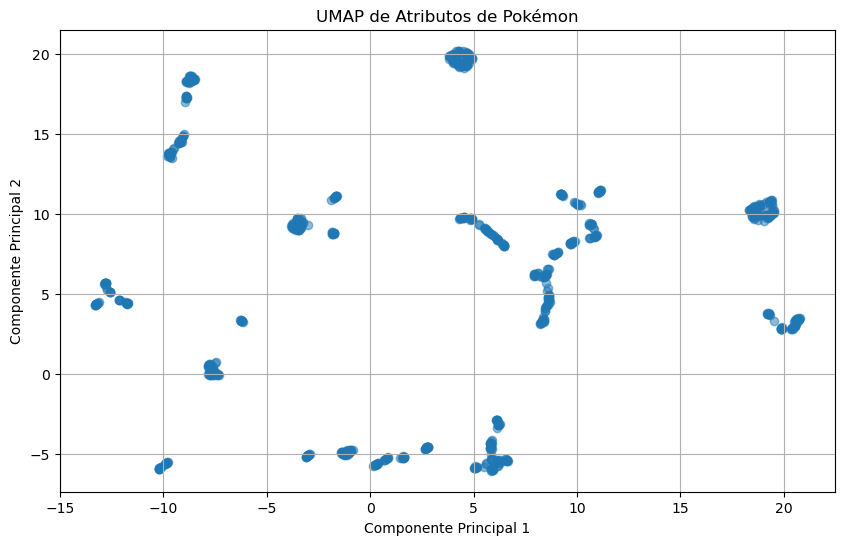

Erro médio quadrático da reconstrução: 0.059671010960309884


In [59]:
#Gráfico dos dois componentes resultantes da aplicação do UMAP
plt.figure(figsize=(10,6))
plt.scatter(umap_df['UMAP1'], umap_df['UMAP2'], alpha=0.5)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('UMAP de Atributos de Pokémon')
plt.grid()
plt.show()

reconstruction = umap_model.inverse_transform(umap_results)

#Comparar o original e reconstruído, por exemplo, com erro médio quadrático (MSE)
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(Z, reconstruction)
print("Erro médio quadrático da reconstrução:", mse)

O método _Uniform Manifold Approximation and Projection (UMAP)_ conseguiu identificar diversos agrupamentos interessantes nos dados, com um erro médio de reconstrução em torno de ~0,05%, indicando uma boa preservação (0,95%) das informações originais. Ao longo deste notebook, aplicaremos diferentes métodos de clustering para analisar as características comuns entre os elementos de cada grupo.

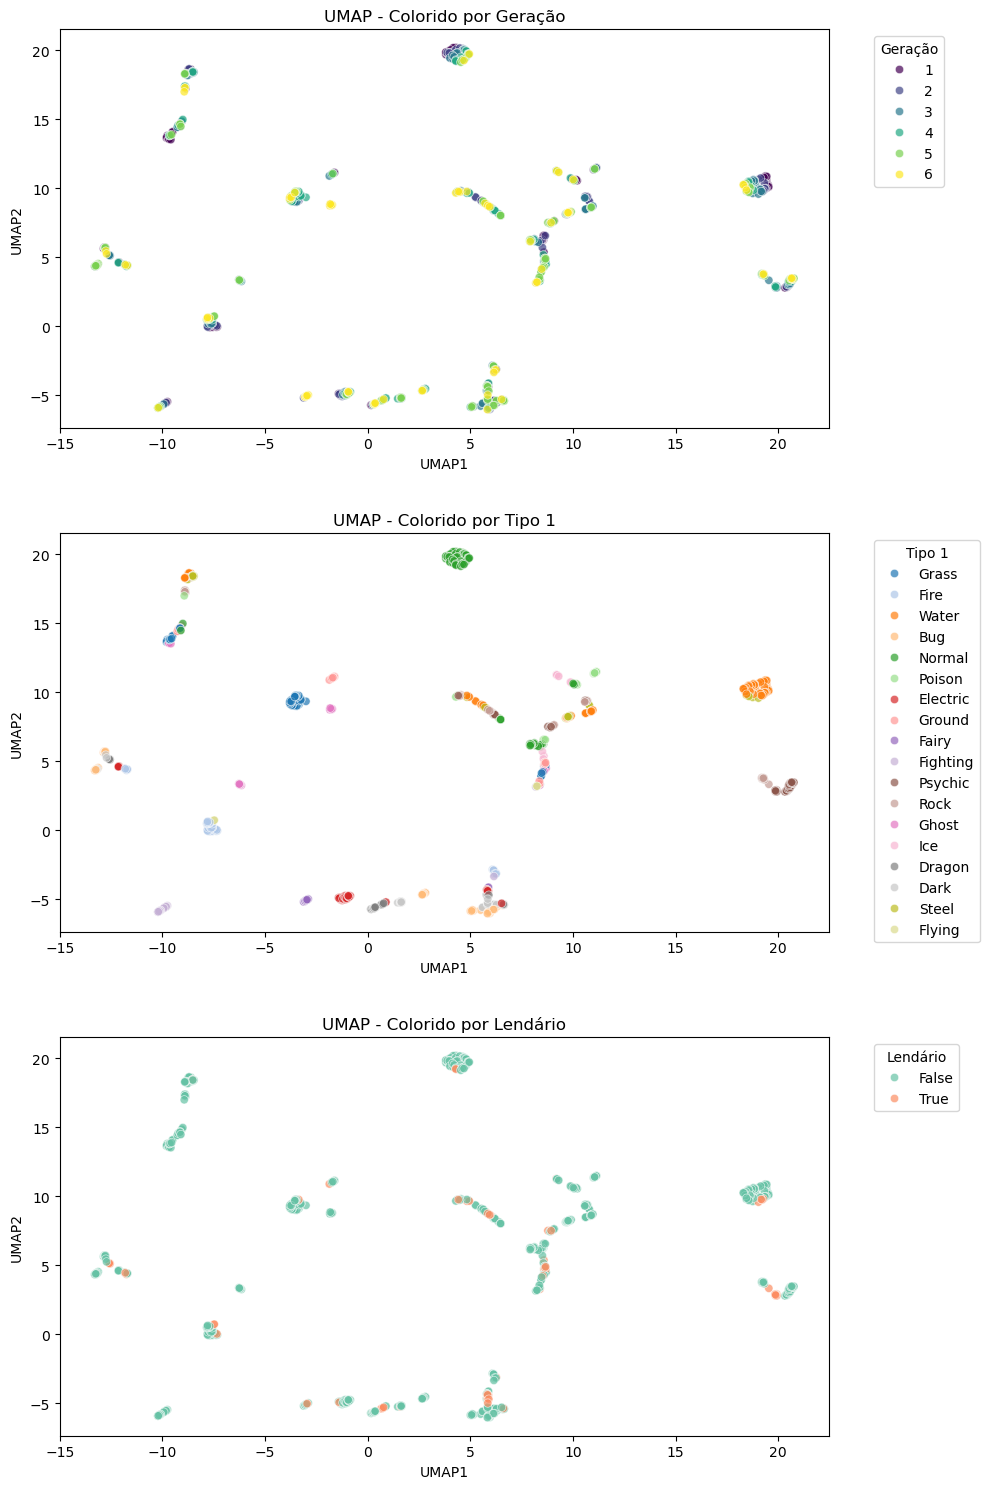

In [61]:
#Gráficos interativos - Ajuste de dimensões
def plot_interactive_clusters(data, clusters, title):
    plot_df = pd.DataFrame({
        'UMAP1': data[:, 0],
        'UMAP2': data[:, 1],
        'Cluster': clusters,
        'Tipo 1': dataset['tipo 1'],
        'Nome': dataset['nome'],
        'Lendário': dataset['lendário'],
        'Geração': dataset['geração']
    })
    
    fig = px.scatter(plot_df, x='UMAP1', y='UMAP2', color='Cluster',
                     hover_data=['Nome', 'Tipo 1', 'Lendário', 'Geração'],
                     title=title,
                     color_continuous_scale=px.colors.qualitative.Set1,
                     width=800, height=600)  # Dimensões ajustadas
    
    fig.update_traces(marker=dict(size=8, opacity=0.7, 
                     line=dict(width=1, color='DarkSlateGrey')),
                     selector=dict(mode='markers'))
    
    fig.show()

#Visualizações UMAP 
plt.figure(figsize=(10, 15))  # Aumentamos a altura para acomodar os 3 gráficos

#Gráfico 1 - Colorido por geração
plt.subplot(3, 1, 1)  # 3 linhas, 1 coluna, posição 1
sns.scatterplot(x='UMAP1', y='UMAP2', hue=dataset['geração'], data=umap_df, palette='viridis', alpha=0.7)
plt.title('UMAP - Colorido por Geração')
plt.legend(title='Geração', bbox_to_anchor=(1.05, 1), loc='upper left')

#Gráfico 2 - Colorido por tipo 1
plt.subplot(3, 1, 2)  # 3 linhas, 1 coluna, posição 2
sns.scatterplot(x='UMAP1', y='UMAP2', hue=dataset['tipo 1'], data=umap_df, palette='tab20', alpha=0.7)
plt.title('UMAP - Colorido por Tipo 1')
plt.legend(title='Tipo 1', bbox_to_anchor=(1.05, 1), loc='upper left')

#Gráfico 3 - Colorido por lendário
plt.subplot(3, 1, 3)  # 3 linhas, 1 coluna, posição 3
sns.scatterplot(x='UMAP1', y='UMAP2', hue=dataset['lendário'], data=umap_df, palette='Set2', alpha=0.7)
plt.title('UMAP - Colorido por Lendário')
plt.legend(title='Lendário', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

No primeiro gráfico observa-se uma presença, relativamente uniforme, de todas as gerações ao longo dos diferentes aglomerados de pontos identificados pelo UMAP. Ainda assim, é possível notar alguns agrupamentos locais, o que pode sugerir a existência de semelhanças entre Pokémon da mesma geração com base nos atributos analisados.

O segundo gráfico mostra uma distribuição equilibrada dos tipos, com agrupamentos distintos para Fogo e Água, que formam clusters densos e bem definidos. O tipo Normal, embora predominante, concentra-se num único agrupamento. Já tipos raros, como Dragão, aparecem mais dispersos, possivelmente devido à sua complexidade ou menor representação.

Os Pokémon lendários aparecem distribuídos em vários clusters, mas concentram-se principalmente em duas áreas: no canto direito (valores altos de UMAP1) e na região inferior central. Estes dois agrupamentos destacam-se pela maior densidade de lendários, mostrando que, embora compartilhem características especiais, existem diferenças significativas que os levam a ocupar posições distintas no espaço reduzido.

#### 3. t-SNE

Tal como o PCA e o UMAP, o t-SNE tem o mesmo objetivo.

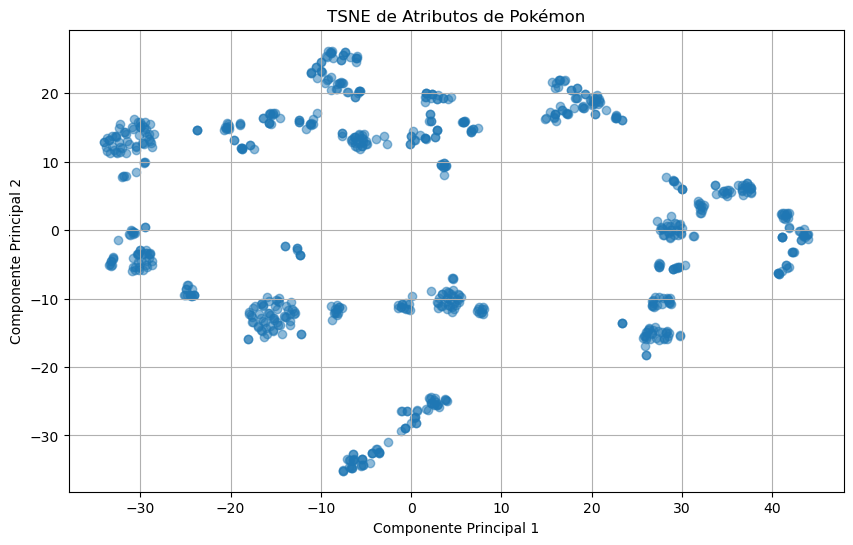

In [65]:
#Gráfico e código da aplicação do t-SNE para dois componentes
tsne = TSNE(n_components=2)
tsne_results = tsne.fit_transform(Z)
tsne_df = pd.DataFrame(data=tsne_results, columns=['TSNE1', 'TSNE2'])
plt.figure(figsize=(10,6))
plt.scatter(tsne_df['TSNE1'], tsne_df['TSNE2'], alpha=0.5)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('TSNE de Atributos de Pokémon')
plt.grid()
plt.show()

O gráfico acima apresenta a projeção bidimensional dos atributos dos Pokémon através do algoritmo t-SNE, uma técnica eficaz para reduzir a dimensionalidade de dados complexos e capturar relações entre a vizinhança. Cada ponto representa um Pokémon, posicionado com base na semelhança dos seus atributos numéricos.

Observa-se a formação de vários agrupamentos bem definidos, indicando que o t-SNE foi capaz de identificar estruturas locais nos dados. Estes clusters sugerem a presença de subgrupos de Pokémon com características semelhantes, por exemplo, agrupamentos entre Pokémons lendários e não lendários. Esta visualização é útil para explorar padrões e orientar futuras etapas da análise, como a aplicação de técnicas de clustering.

## **5. Modelação com algoritmos de clustering**

#### KMeans com os dados reduzidos pelo UMAP utilizando o método de avaliação de Elbow

Este código utiliza o Método do Cotovelo (Elbow method) para determinar o número ideal de clusters no algoritmo KMeans. Calcula a soma das distâncias quadráticas dentro dos clusters (WCSS) para diferentes valores de K (de 1 a 10) e cria um gráfico para ajudar a identificar o ponto de inflexão, indicando o número ótimo de clusters.

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

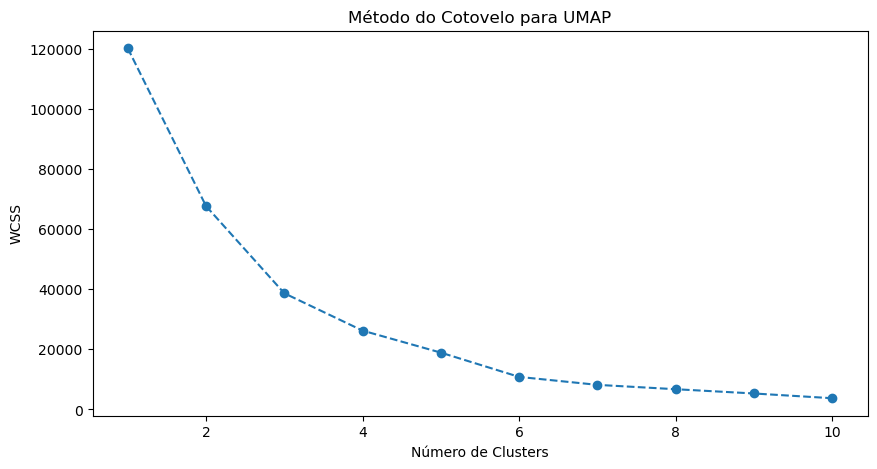

In [70]:
#Método do cotovelo para KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=1)
    kmeans.fit(umap_results)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS')
plt.title('Método do Cotovelo para UMAP')
plt.show()

A curva apresenta uma diminuição acentuada até K=4, onde começa a suavizar, formando um "cotovelo". Isso indica que 4 clusters é o número ideal, pois adicionar mais clusters não melhora significativamente a compactação dos dados, enquanto que menos clusters resultariam em grupos menos refinados. Portanto, K=4 oferece o melhor equilíbrio entre precisão e simplicidade.

#### K-Means

Este código aplica o algoritmo KMeans para agrupar os dados em 4 categorias diferentes, pois com o método do cotovelo foi definido que o numero ideal de clusters seriam 4.

In [74]:
#Aplicação de KMeans
kmeans = KMeans(n_clusters=4, random_state=1)
clusters_kmeans = kmeans.fit_predict(umap_results)
umap_df['Cluster_KMeans'] = clusters_kmeans
dataset['Cluster_KMeans'] = clusters_kmeans

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Como o método do cotovelo (Elbow Method) indicou que o número ideal de clusters seria quatro, o algoritmo K-Means foi ajustado para criar quatro partições distintas, abrangendo os 800 Pokémon presentes no dataset.
No entanto, sendo o K-Means insensível à presença de outliers, estes foram forçadamente atribuídos a um dos quatro clusters, não havendo, através desta técnica, possibilidade de os diferenciar adequadamente.
A entrada dos dados no algoritmo foi realizada com base na redução dimensional para duas dimensões, obtida através do UMAP.

#### DBSCAN

O algoritmo DBSCAN é utilizado para agrupar os dados tendo em conta a sua densidade.

In [78]:
#Aplicação de DBSCAN
dbscan = DBSCAN(eps=0.9, min_samples=20)
clusters_dbscan = dbscan.fit_predict(umap_results)
umap_df['Cluster_DBSCAN'] = clusters_dbscan
dataset['Cluster_DBSCAN'] = clusters_dbscan

Diferente da abordagem do K-Means, o DBSCAN utiliza a abordagem baseada em densidade local no espaço de dados reduzidos pelo umap.. 

Sendo uma técnica que apresenta uma vantagem clara face ao K-Means no tratamento de outliers, foi possível identificar 119 Pokémon considerados atípicos, agrupados num cluster -1, caracterizado por uma baixa densidade.
Este resultado indica a presença de valores isolados e fora do padrão, que o algoritmo conseguiu separar eficazmente.
Ao contrário do K-Means, que tende a atribuir esses valores ao cluster mais próximo, esta abordagem permite distinguir e isolar os outliers.


#### Visualização


KMeans Clusters - Visualização Interativa:


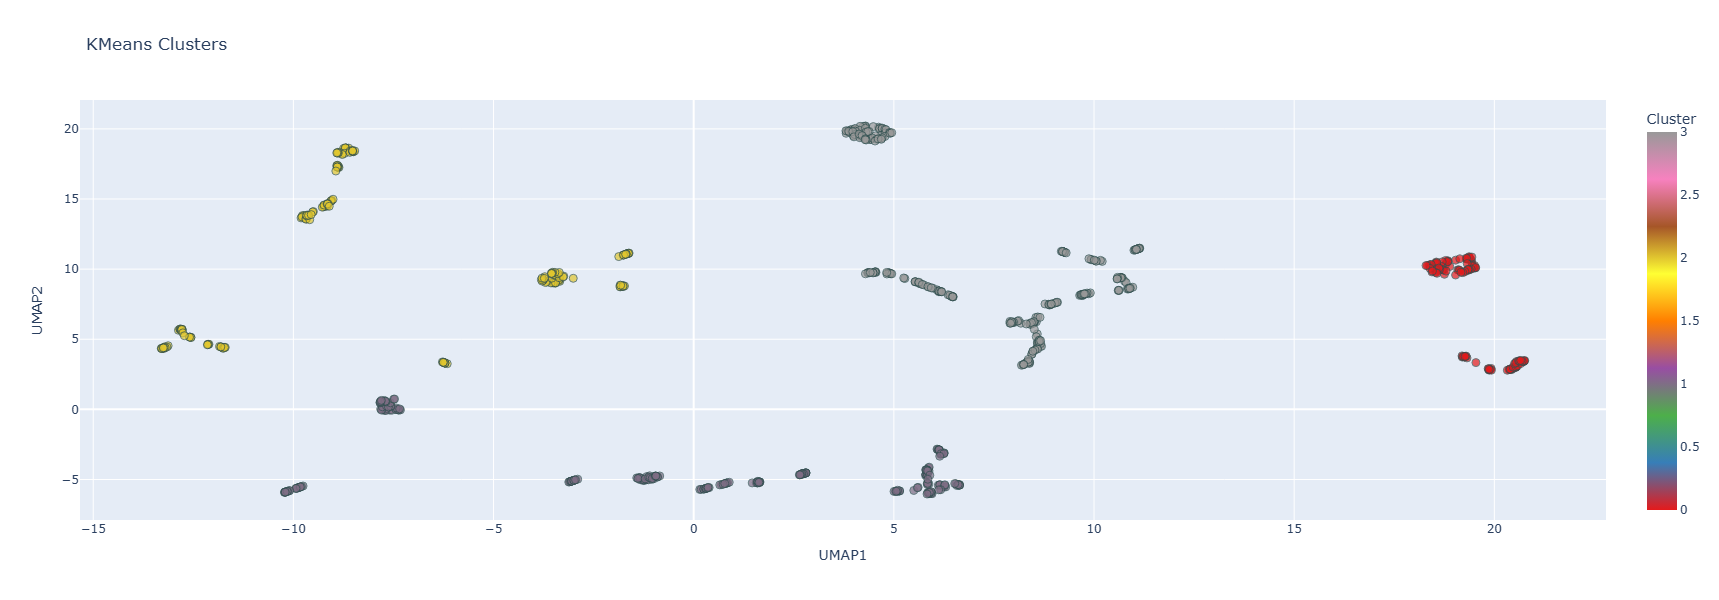


DBSCAN Clusters - Visualização Interativa:


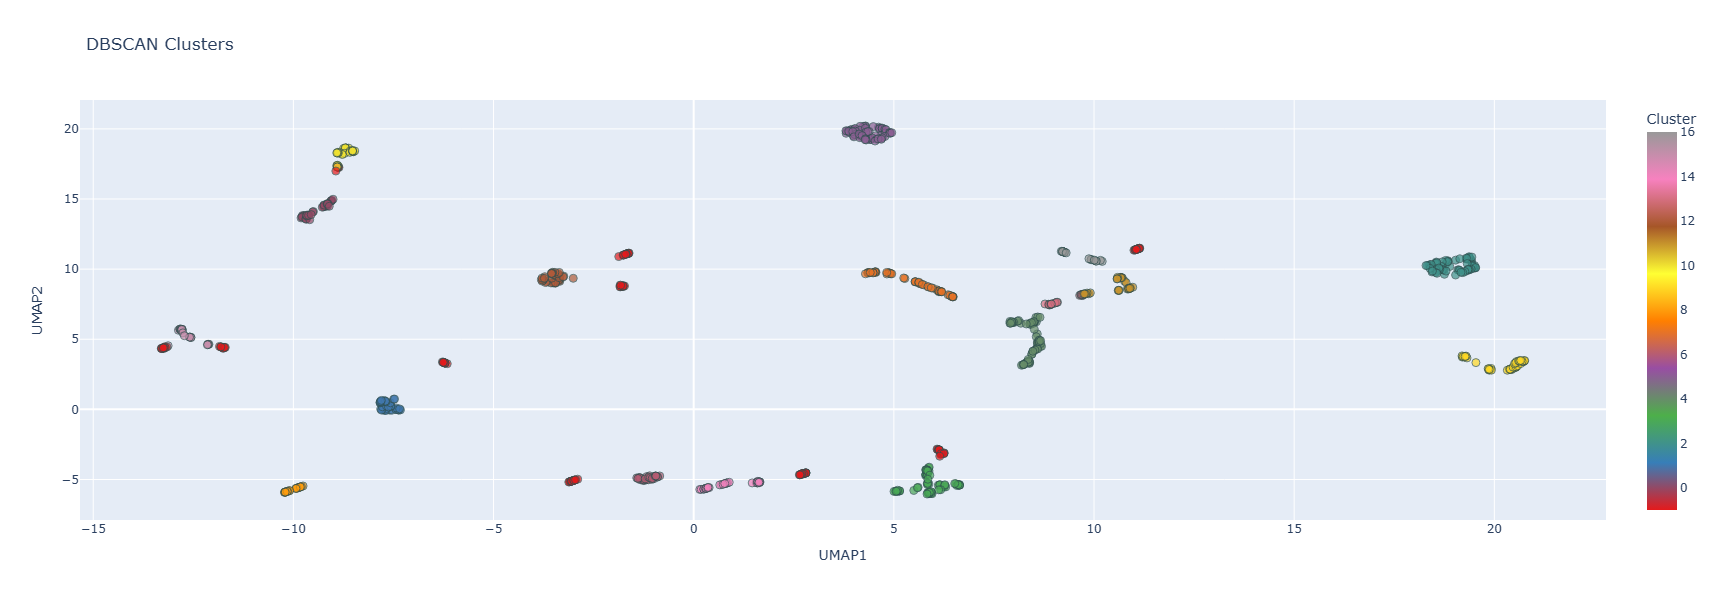

In [81]:
print("\nKMeans Clusters - Visualização Interativa:")
plot_interactive_clusters(umap_results, clusters_kmeans, 'KMeans Clusters')

print("\nDBSCAN Clusters - Visualização Interativa:")
plot_interactive_clusters(umap_results, clusters_dbscan, 'DBSCAN Clusters')

Estes gráficos interativos revelam-se vantajosos, uma vez que permitem explorar os diferentes valores associados a cada cluster, oferecendo uma visualização dos dados numa escala macro.

As fronteiras definidas anteriormente pelo K-Means, aplicadas ao mesmo conjunto de dados reduzidos pelo UMAP, diferem significativamente, tanto na sua localização, como nos limites entre clusters.

É possível visualizar a cinzento os outliers identificados após a aplicação directa do DBSCAN, destacando-se, na zona aproximada de (6, 10), um pequeno agrupamento de outliers que inclui vários Pokémon lendários.
Além disso, ao aplicar zoom sobre determinadas regiões, é possível distinguir outliers localizados nas zonas limítrofes de alguns clusters.



Dashboard de Análise por Cluster - KMeans:


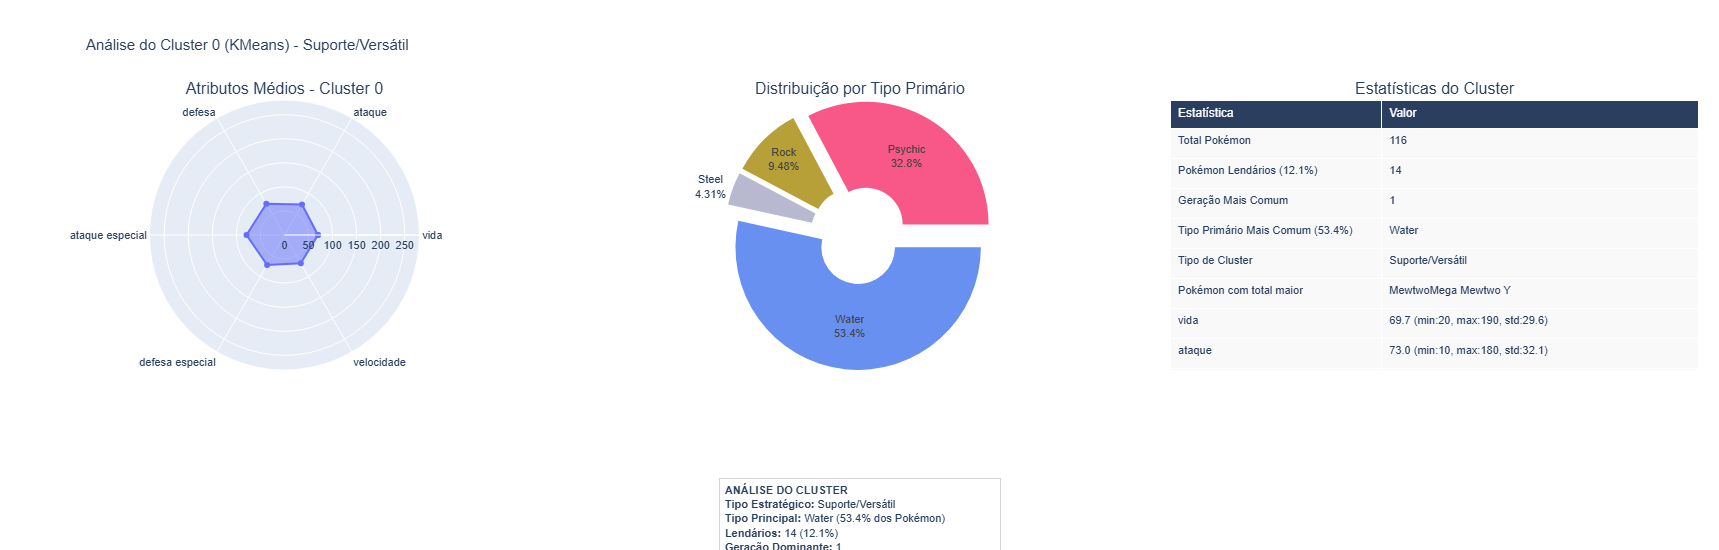

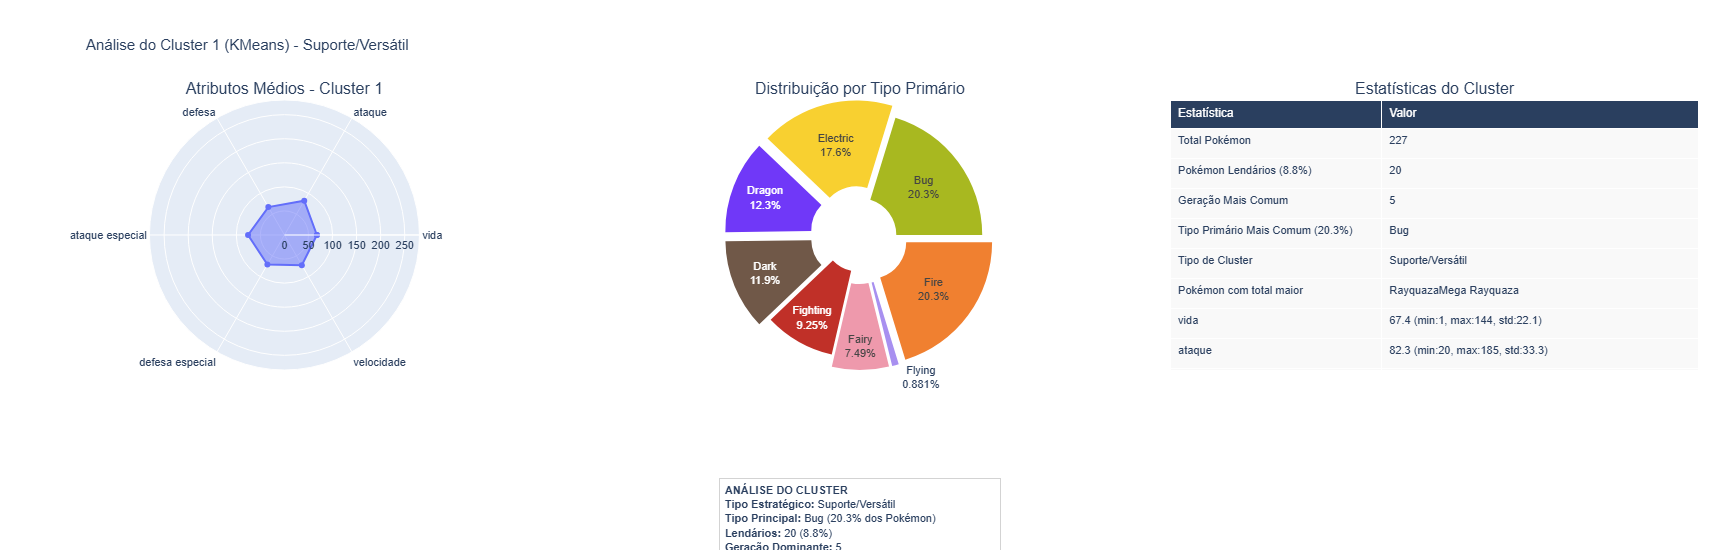

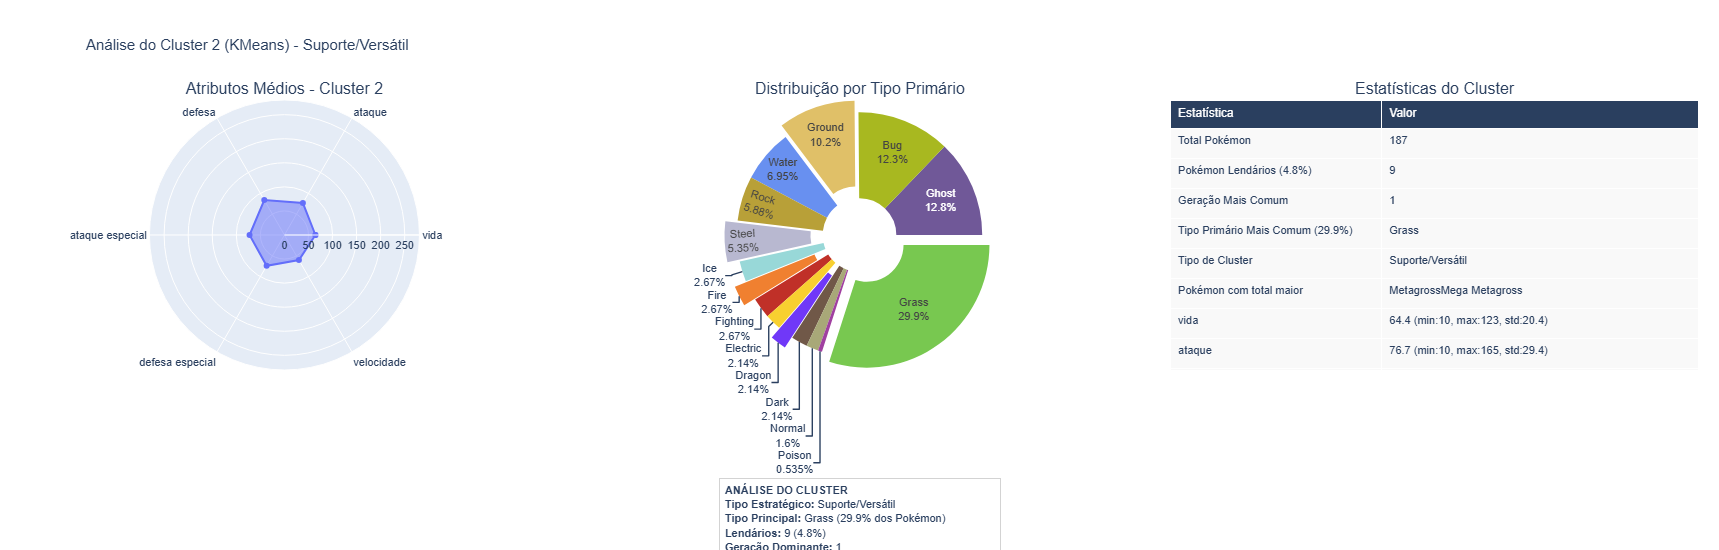

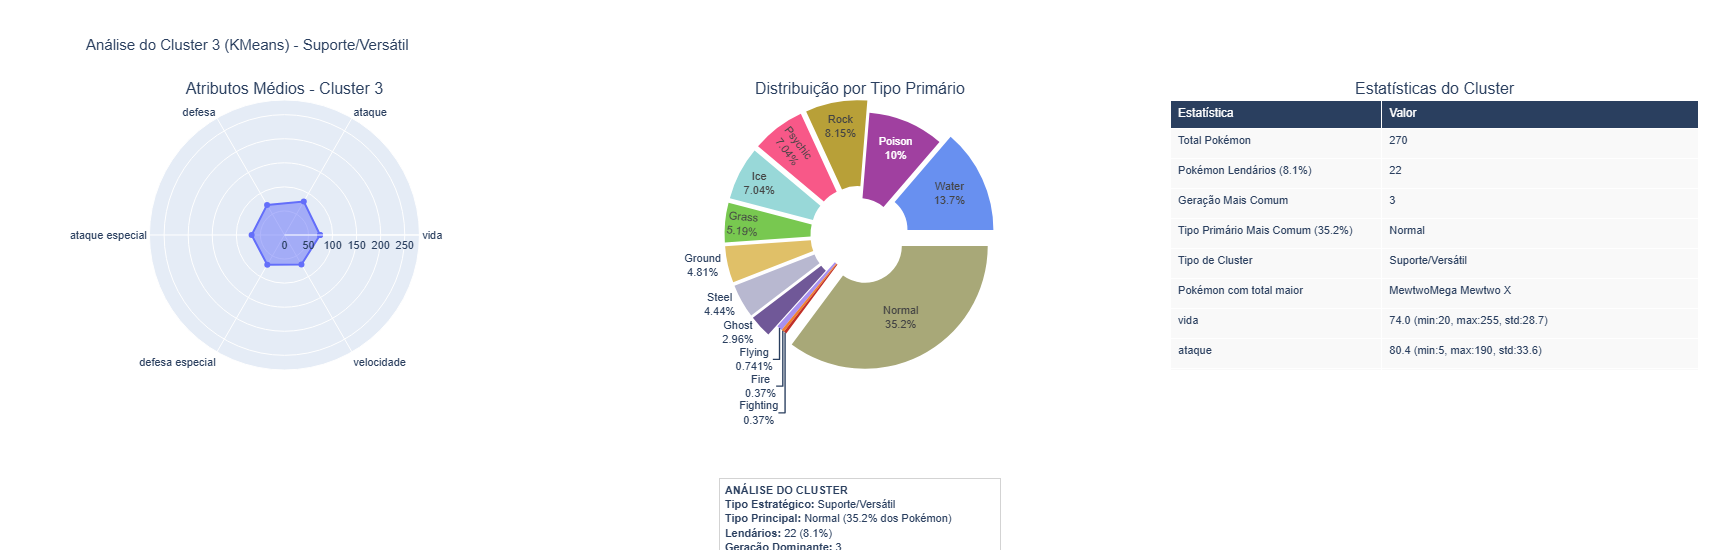


Dashboard de Análise por Cluster - DBSCAN:


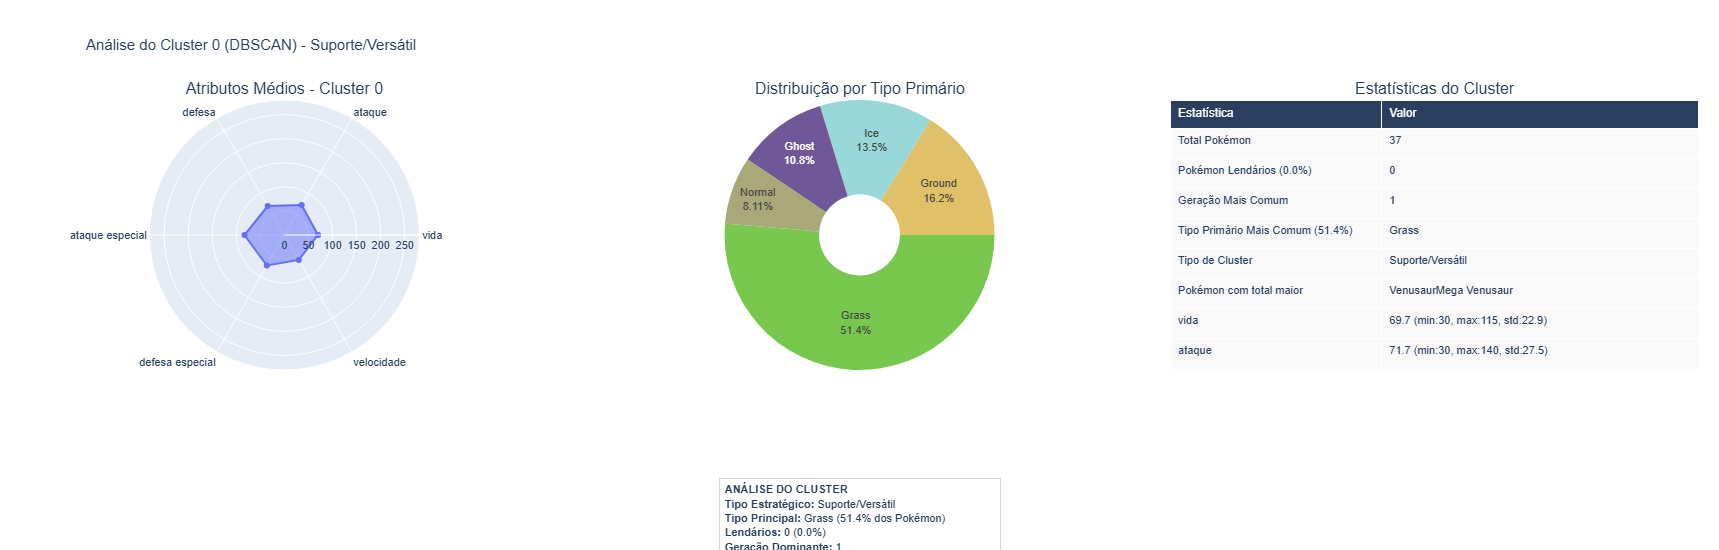

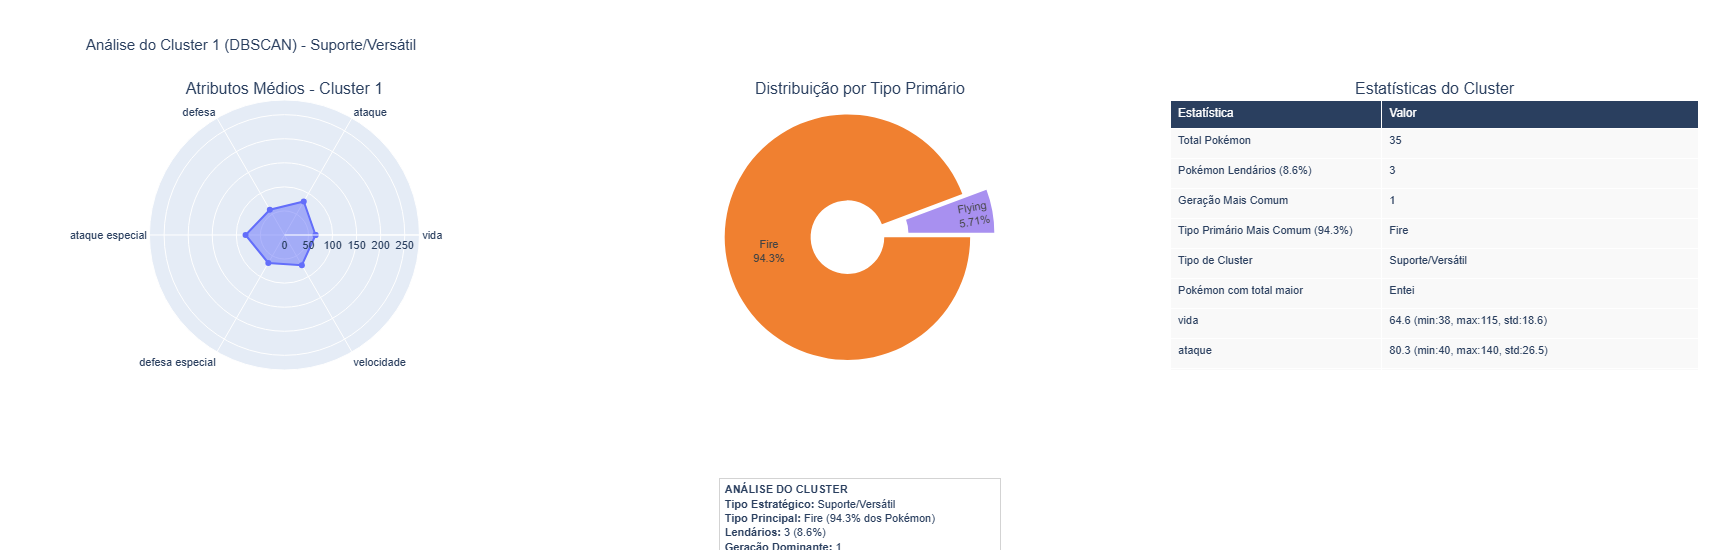

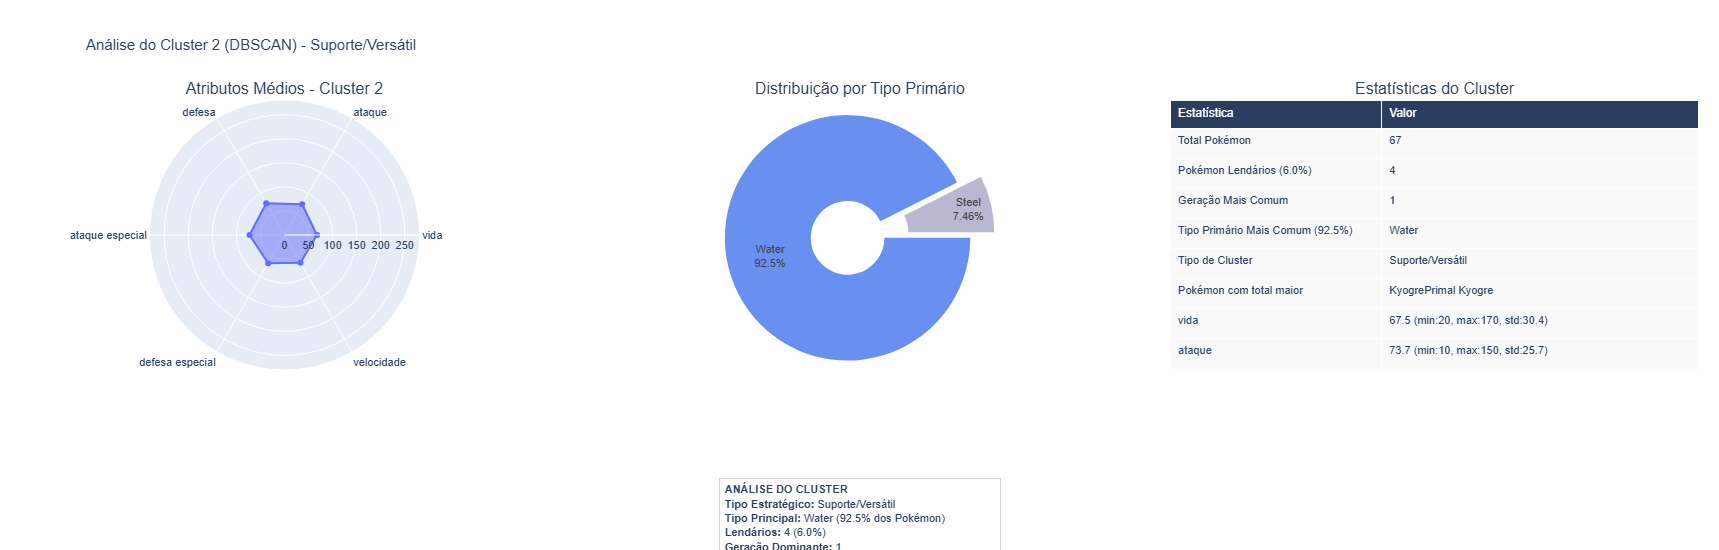

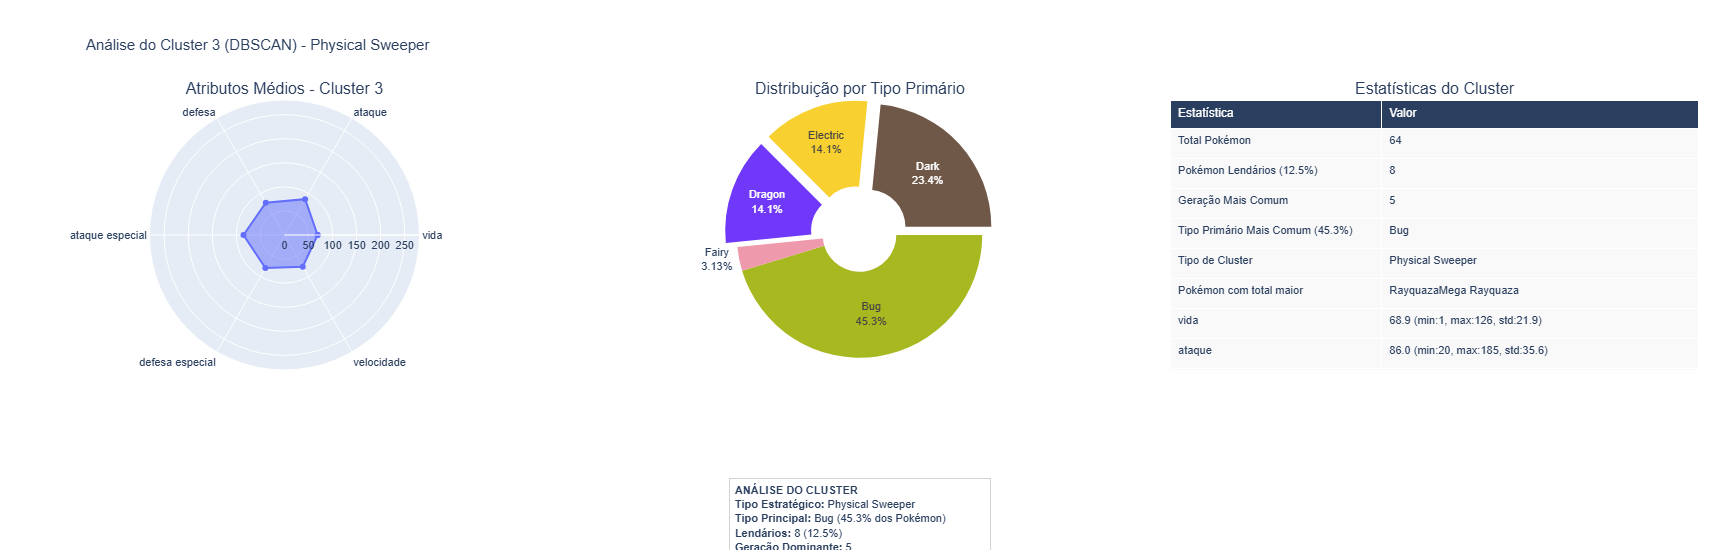

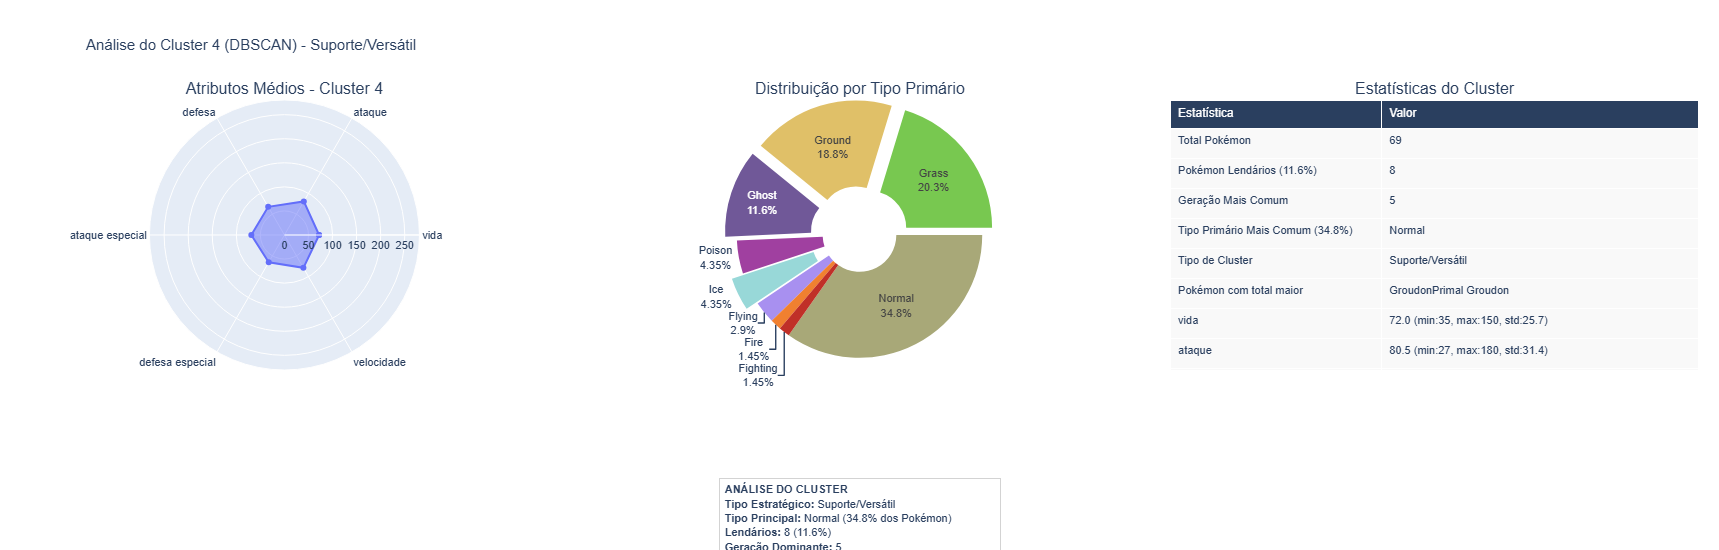

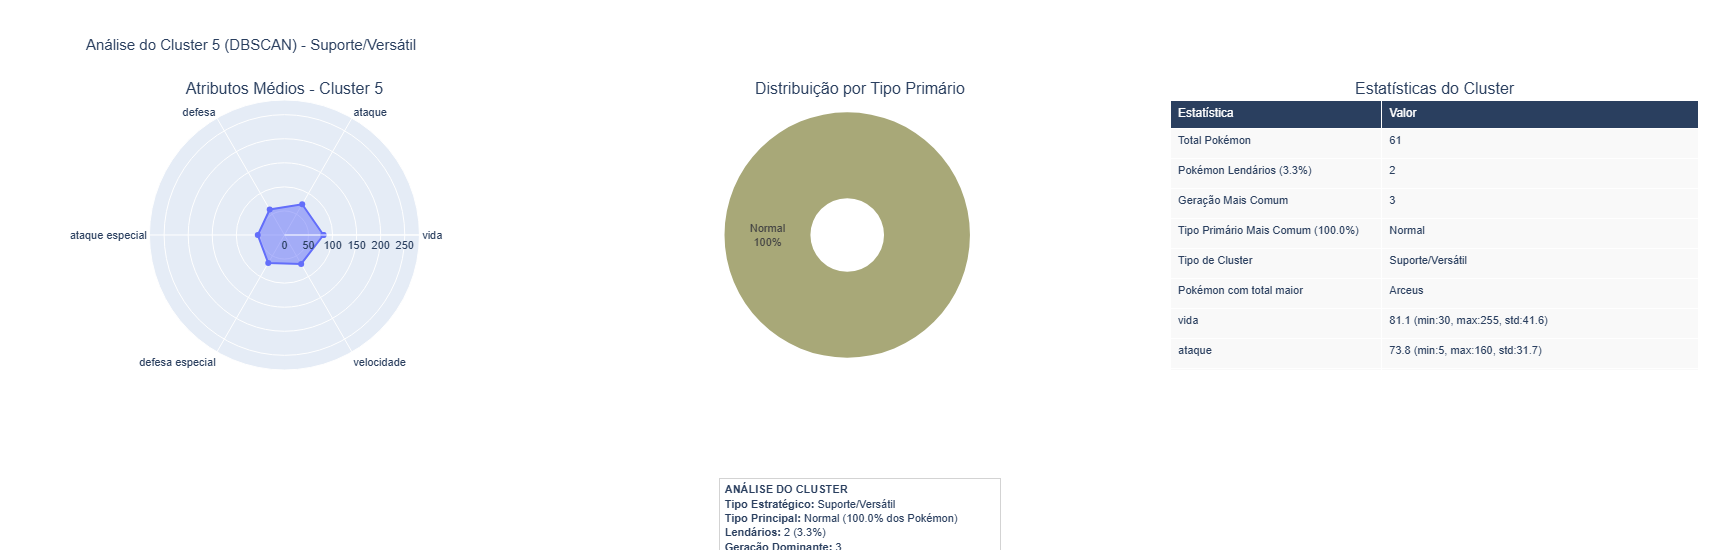

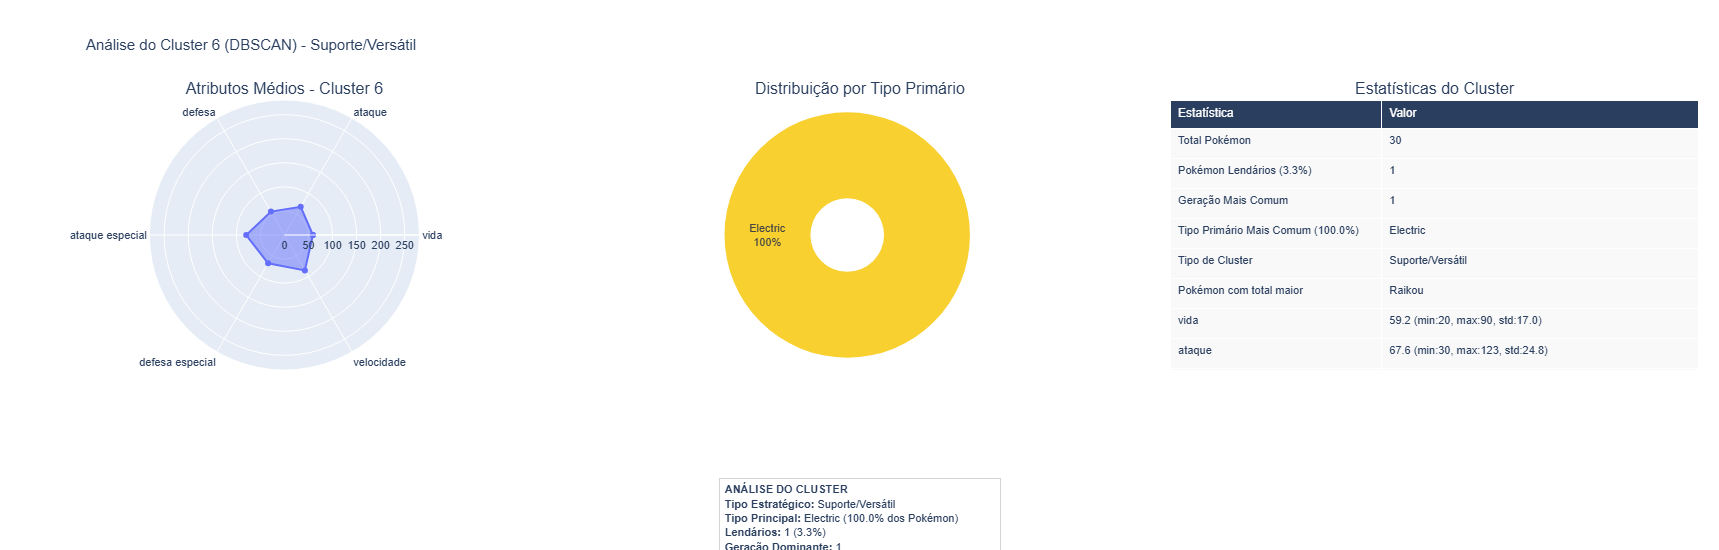

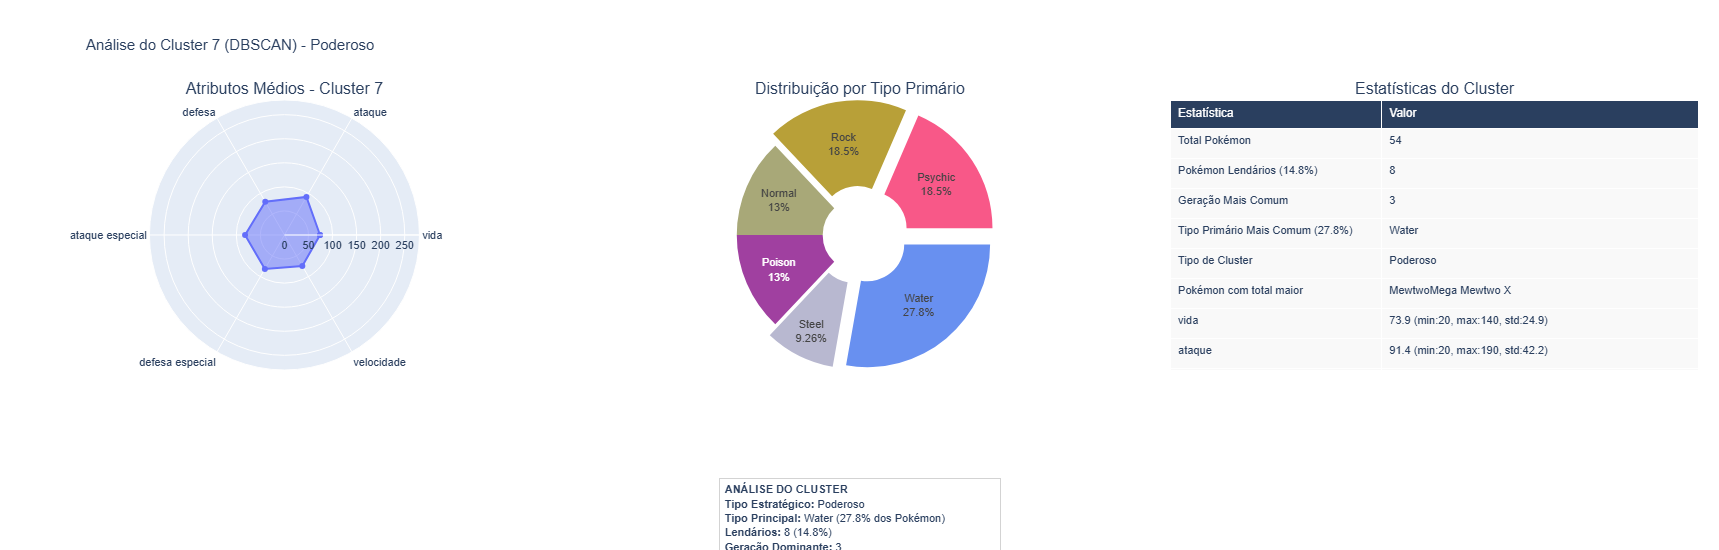

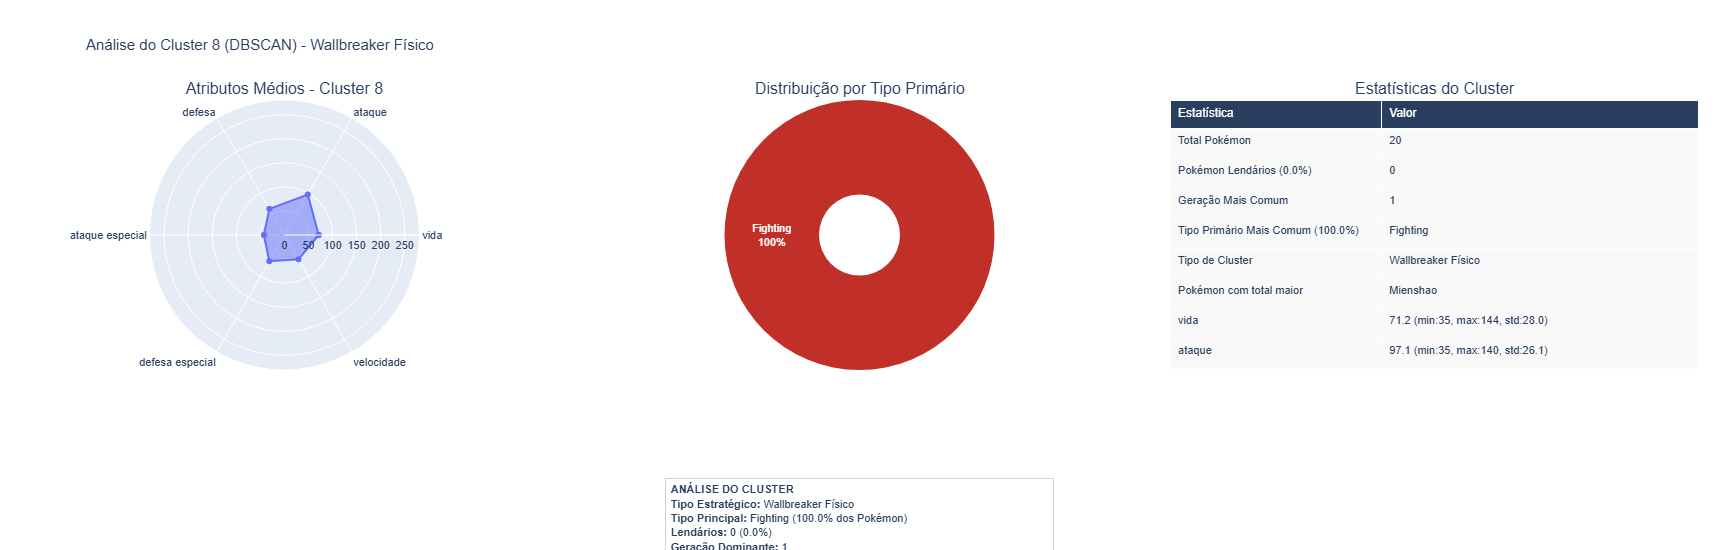

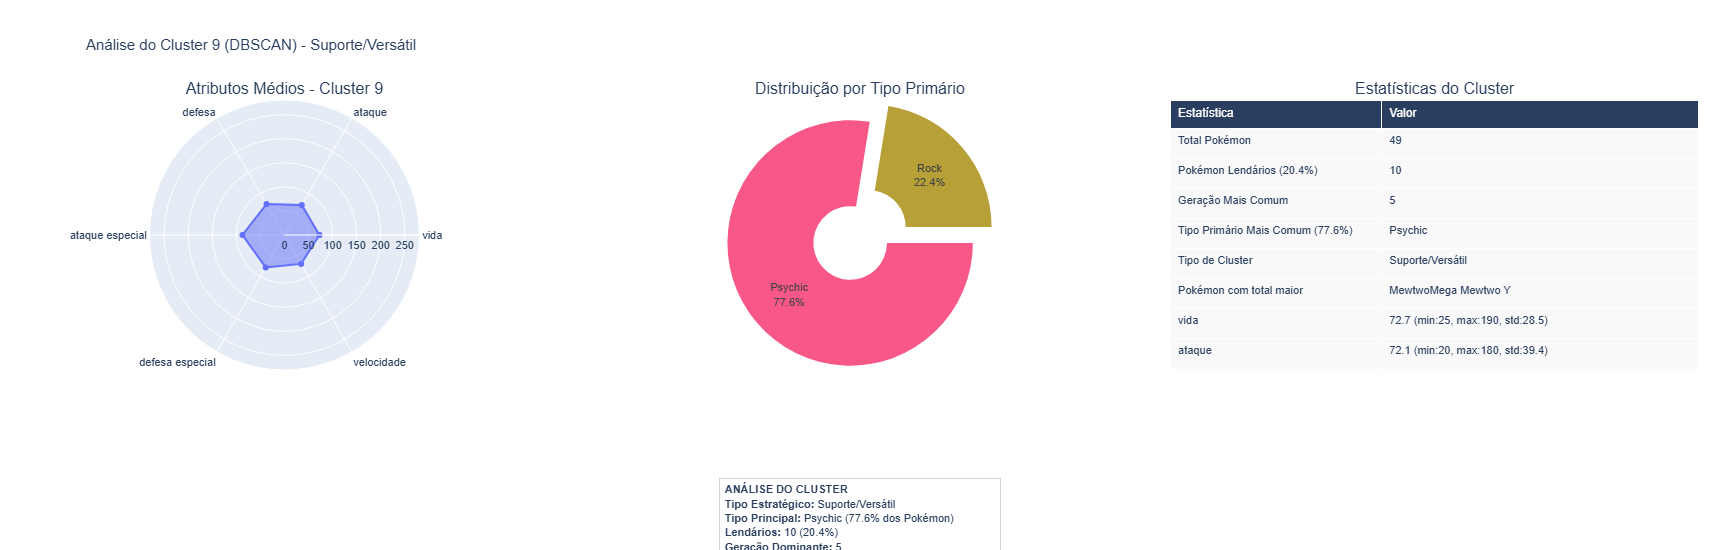

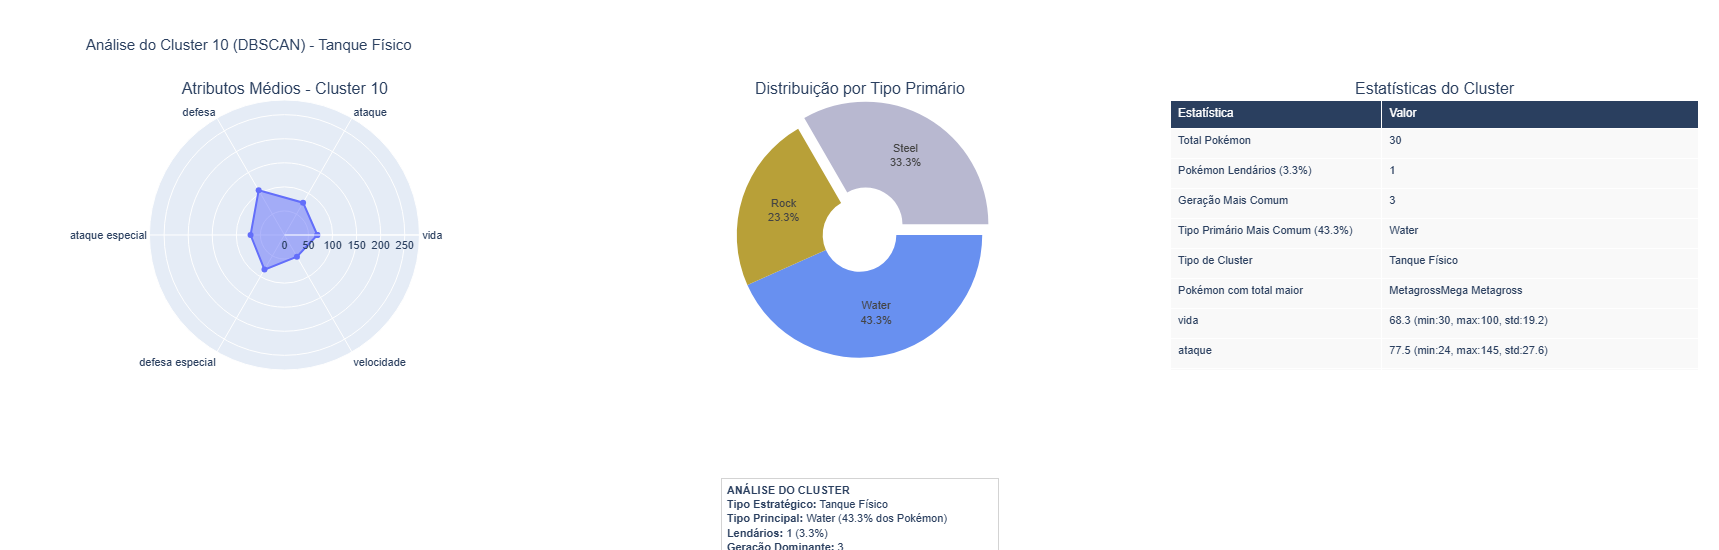

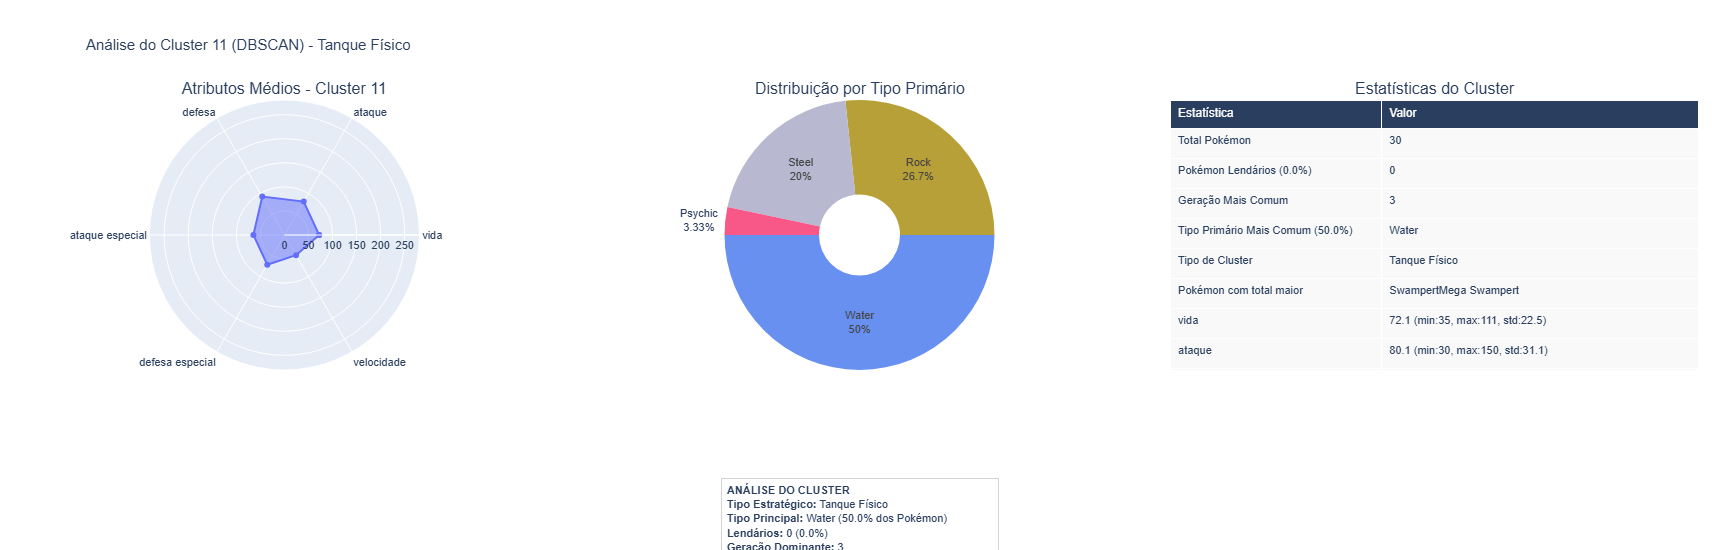

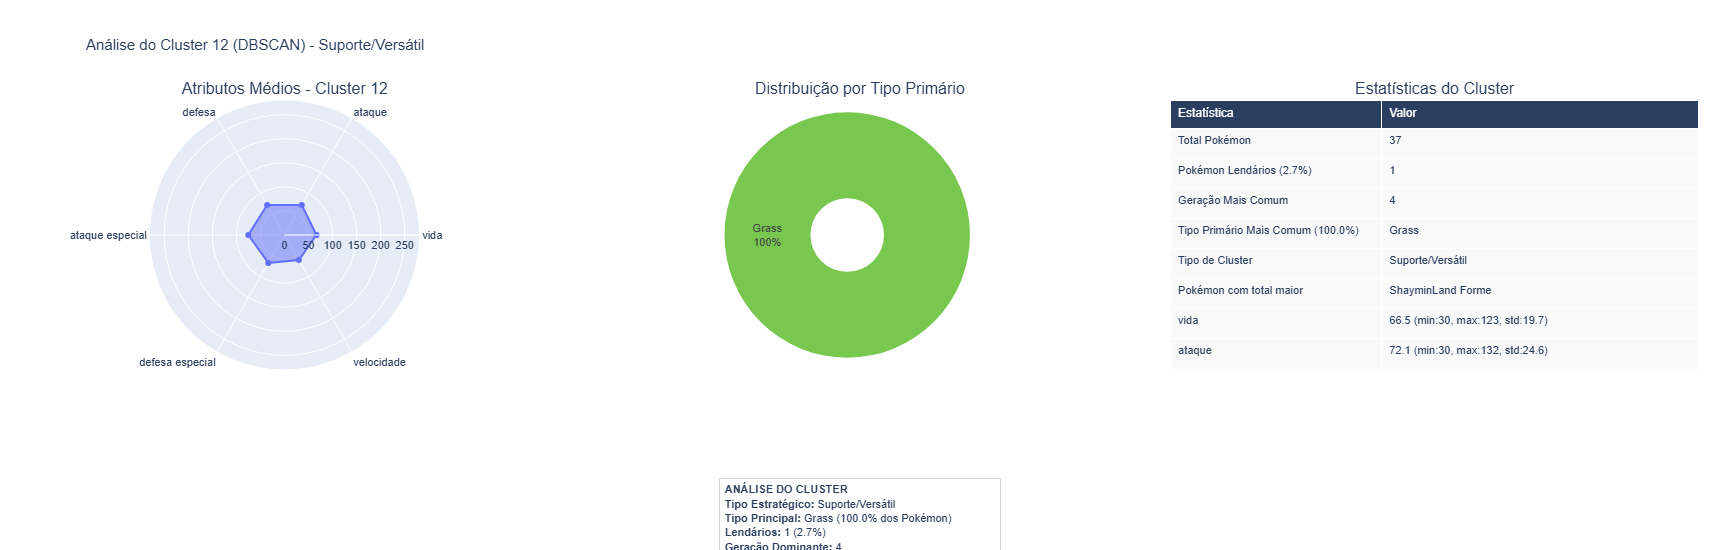

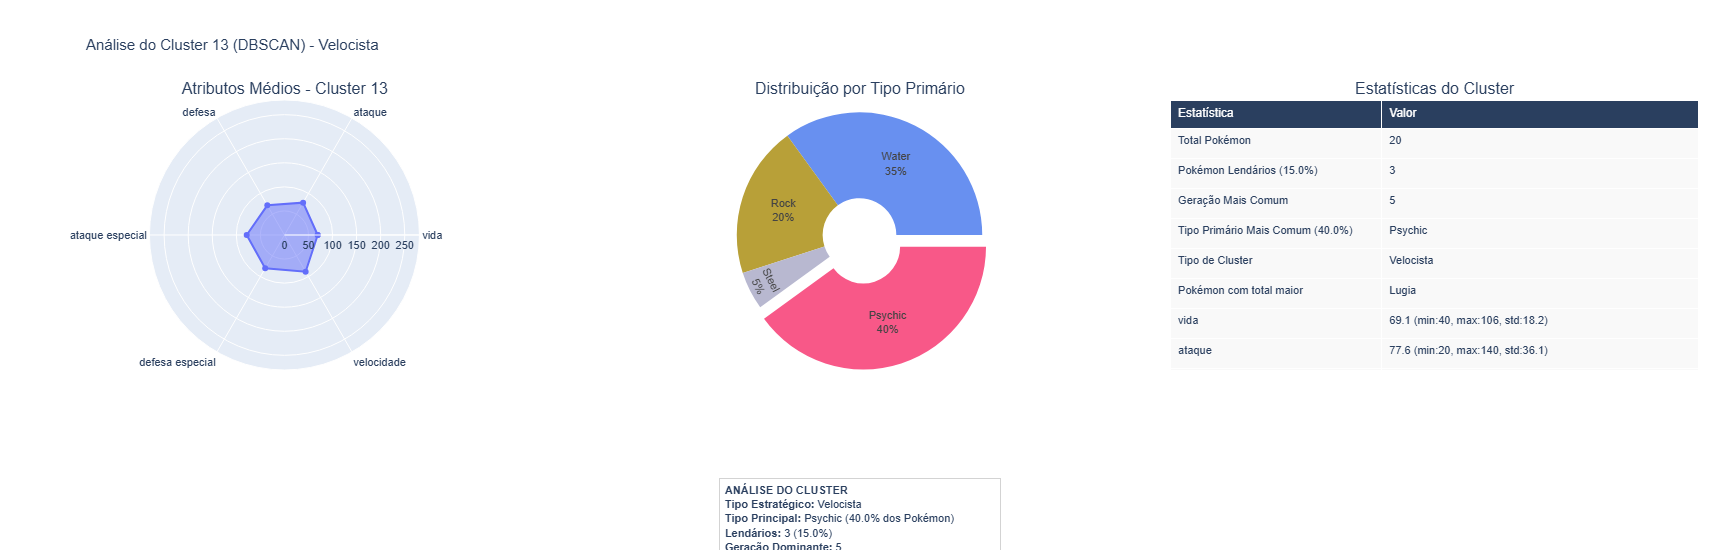

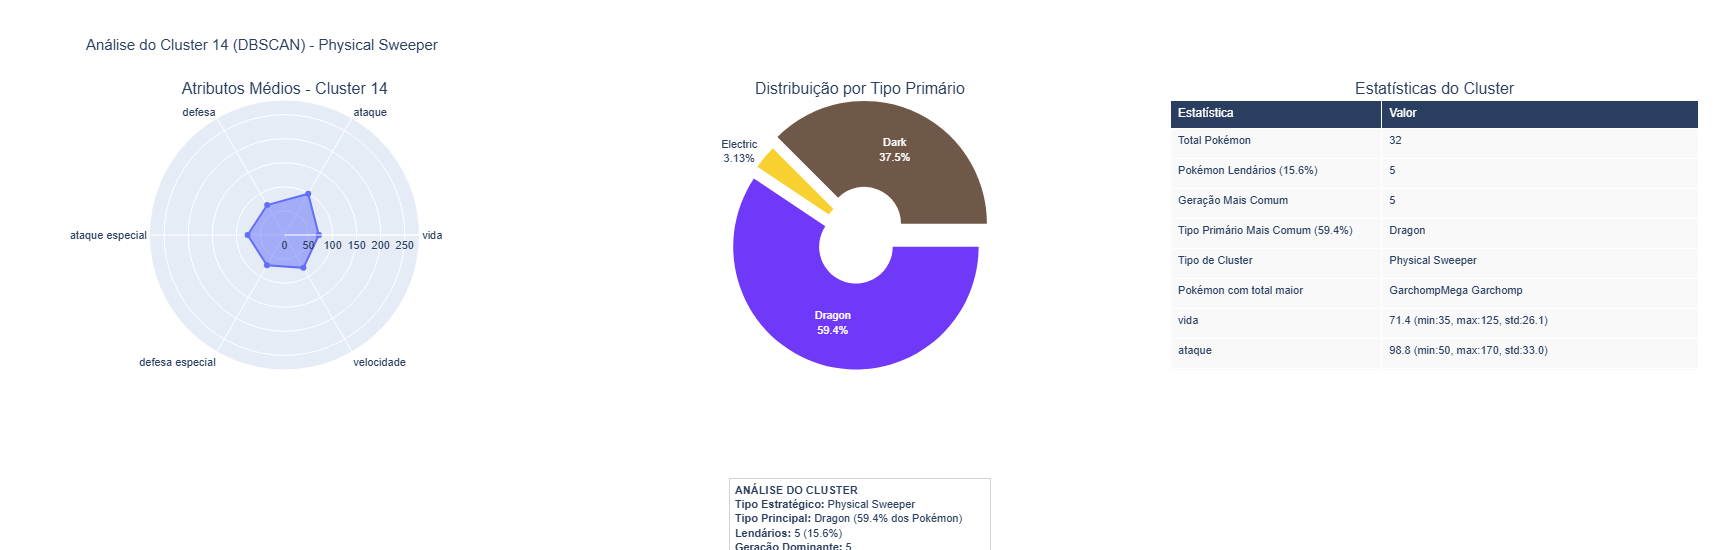

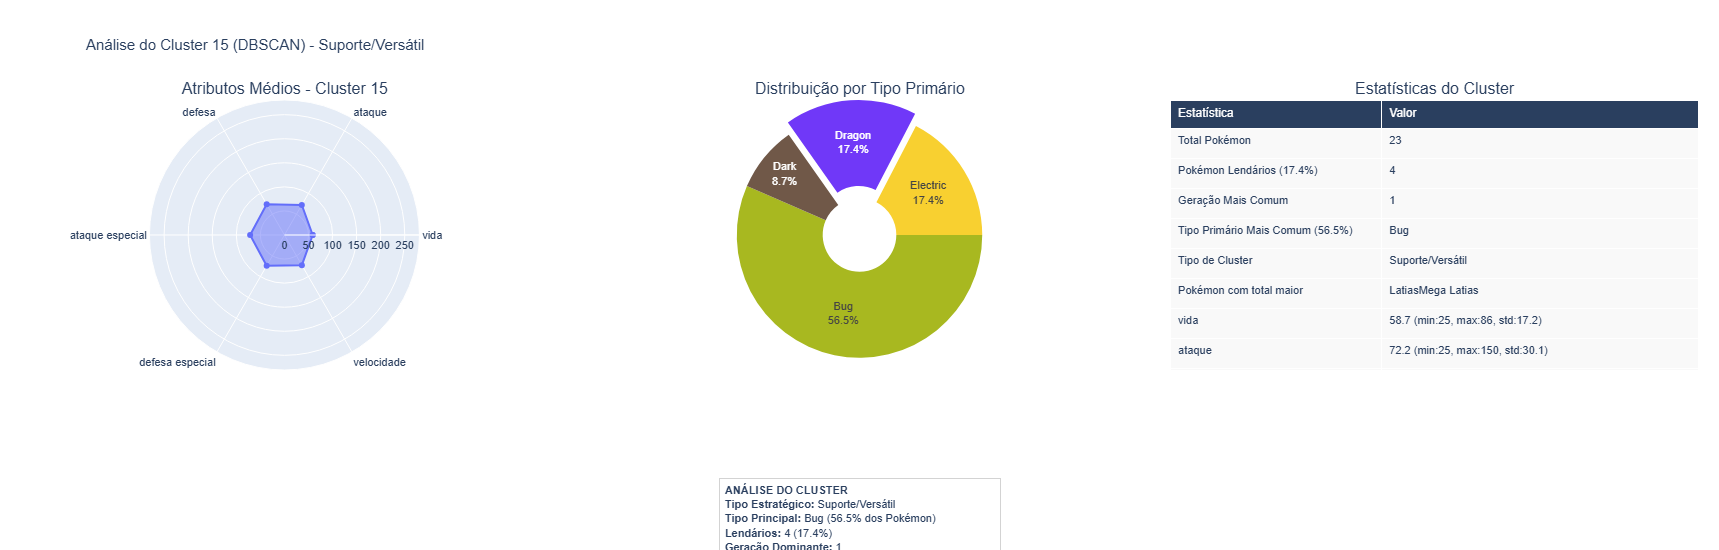

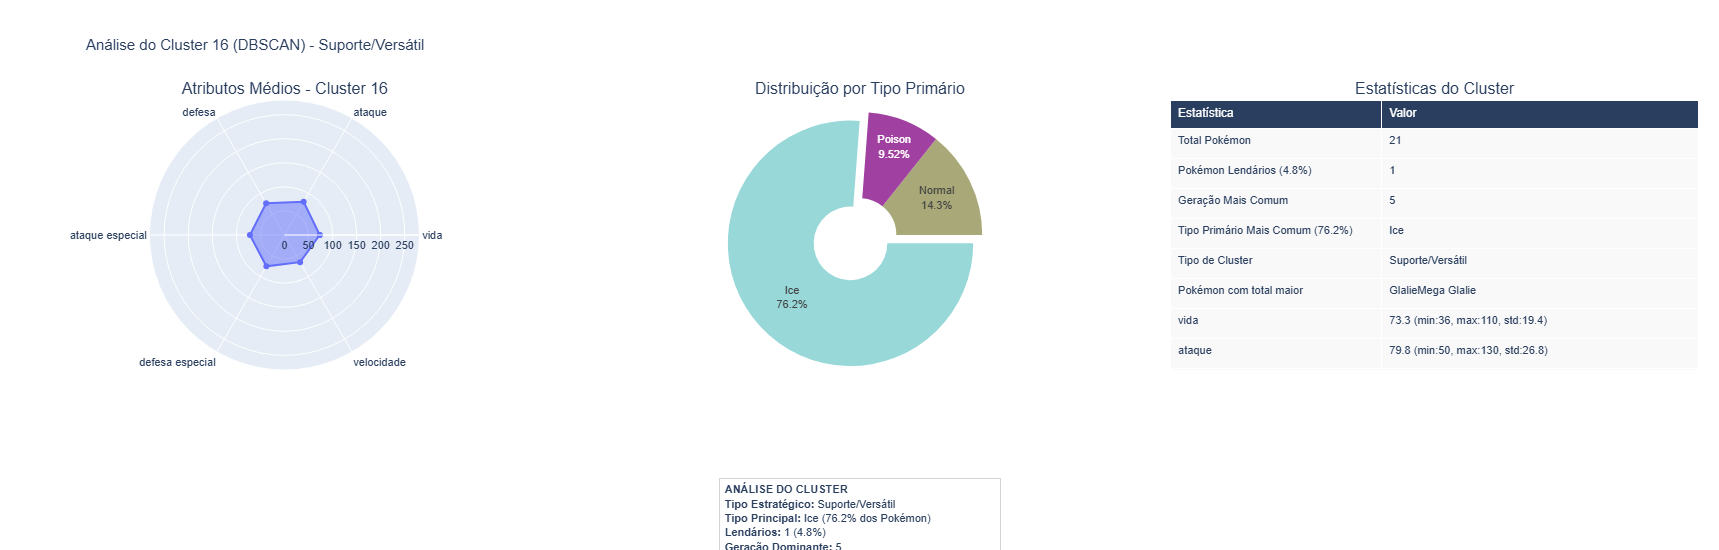

In [83]:
def plot_cluster_dashboard(clusters, method_name):
    categories = ['vida', 'ataque', 'defesa', 'ataque especial', 'defesa especial', 'velocidade']
    unique_clusters = np.unique(clusters[clusters != -1])  # Excluir outliers
    
    #Mapeamento de cores fixas para cada tipo primário
    type_colors = {
        'Grass': '#78C850', 'Fire': '#F08030', 'Water': '#6890F0',
        'Bug': '#A8B820', 'Normal': '#A8A878', 'Poison': '#A040A0',
        'Electric': '#F8D030', 'Ground': '#E0C068', 'Fairy': '#EE99AC',
        'Fighting': '#C03028', 'Psychic': '#F85888', 'Rock': '#B8A038',
        'Ghost': '#705898', 'Ice': '#98D8D8', 'Dragon': '#7038F8',
        'Dark': '#705848', 'Steel': '#B8B8D0', 'Flying': '#A890F0',
        'Inexistente': '#000000'
    }
    
    for cluster in unique_clusters:
        #Dados do cluster
        cluster_data = dataset[clusters == cluster]
        stats_mean = cluster_data[categories].mean().round(1)
        stats_min = cluster_data[categories].min().round(1)
        stats_max = cluster_data[categories].max().round(1)
        stats_std = cluster_data[categories].std().round(1)
        
        total_pokemon = len(cluster_data)
        legendary_count = cluster_data['lendário'].sum()
        legendary_percent = round((legendary_count / total_pokemon * 100), 1)
        most_common_gen = cluster_data['geração'].mode()[0]
        most_common_type = cluster_data['tipo 1'].mode()[0]
        most_common_type_count = cluster_data['tipo 1'].value_counts().max()
        most_common_type_percent = round((most_common_type_count / total_pokemon * 100), 1)
        
        #Pokémon com soma de total maior
        strongest_pokemon = cluster_data.loc[cluster_data['total'].idxmax()]['nome']
        
        #Determinar a tipologia do cluster
        cluster_type = determine_cluster_type(stats_mean)
        
        #Criar figura
        fig = make_subplots(
            rows=1, cols=3,
            specs=[[{'type': 'polar'}, {'type': 'pie'}, {'type': 'table'}]],
            column_widths=[0.35, 0.3, 0.35],
            subplot_titles=(f'Atributos Médios - Cluster {cluster}', 
                          'Distribuição por Tipo Primário',
                          'Estatísticas do Cluster'),
            horizontal_spacing=0.05
        )
        
        #Radar Plot
        fig.add_trace(go.Scatterpolar(
            r=stats_mean.tolist() + [stats_mean[0]],
            theta=categories + [categories[0]],
            fill='toself',
            name=f'Cluster {cluster}',
            line_color='#636EFA',
            marker_color='#636EFA'
        ), row=1, col=1)
        
        max_value = dataset[categories].max().max()
        fig.update_polars(radialaxis_range=[0, max_value*1.1], row=1, col=1)
        
        #Pie Chart (Tipos Primários)
        type_counts = cluster_data['tipo 1'].value_counts()
        legendaries = cluster_data[cluster_data['lendário'] == True]
        legendary_counts = legendaries['tipo 1'].value_counts()
        
        #Preparar cores e destaque para lendários
        colors = []
        pull_values = []
        for t in type_counts.index:
            colors.append(type_colors.get(t, '#000000'))
            if t in legendary_counts:
                pull_values.append(0.1)
            else:
                pull_values.append(0)
        
        fig.add_trace(go.Pie(
            labels=type_counts.index,
            values=type_counts.values,
            name=f'Tipos Cluster {cluster}',
            marker=dict(colors=colors),
            textinfo='percent+label',
            hole=0.3,
            pull=pull_values,
            rotation=90
        ), row=1, col=2)
        
        #Preparar dados para tabela
        stats_with_details = []
        for cat in categories:
            stats_with_details.append(
                f"{stats_mean[cat]} (min:{stats_min[cat]}, max:{stats_max[cat]}, std:{stats_std[cat]})"
            )
        
        #Tabela de Estatísticas
        stats_table = pd.DataFrame({
            'Estatística': [
                'Total Pokémon', 
                f"Pokémon Lendários ({legendary_percent}%)",
                'Geração Mais Comum', 
                f"Tipo Primário Mais Comum ({most_common_type_percent}%)",
                'Tipo de Cluster',
                'Pokémon com total maior'
            ] + categories,
            'Valor': [
                total_pokemon,
                f"{legendary_count}",
                most_common_gen,
                most_common_type,
                cluster_type,
                strongest_pokemon
            ] + stats_with_details
        })
        
        fig.add_trace(go.Table(
            header=dict(
                values=['Estatística', 'Valor'],
                fill_color='#2a3f5f',
                align='left',
                font=dict(color='white', size=12)
            ),
            cells=dict(
                values=[stats_table['Estatística'], stats_table['Valor']],
                fill_color='#f9f9f9',
                align='left',
                font=dict(size=11),
                height=30
            ),
            columnorder=[0,1],
            columnwidth=[0.4,0.6]
        ), row=1, col=3)
        
        # Layout final
        fig.update_layout(
            title_text=f'Análise do Cluster {cluster} ({method_name}) - {cluster_type}',
            showlegend=False,
            width=1300,
            height=550,
            margin=dict(l=20, r=20, t=100, b=180),
            font=dict(family="Arial", size=11)
        )
        
        #Descrição detalhada do cluster
        description = generate_cluster_description(
            stats_mean, cluster_type, most_common_type, 
            legendary_count, most_common_gen, total_pokemon,
            most_common_type_percent
        )
        
        fig.add_annotation(
            x=0.5, y=-0.4,
            xref="paper", yref="paper",
            text=description,
            showarrow=False,
            font=dict(size=11),
            align="left",
            xanchor="center",
            yanchor="top",
            bordercolor="lightgray",
            borderwidth=1,
            borderpad=4,
            bgcolor="white"
        )
        
        fig.show()

def determine_cluster_type(stats):
    """Classifica o cluster baseado nas estatísticas médias com thresholds ajustados"""
    # Primeiro verificar clusters com estatísticas altas em geral
    if stats.mean() > 80:
        return "Poderoso"
    
    # Casos defensivos (valores mais baixos pois a defesa raramente passa de 100)
    if stats['defesa'] > 85 and stats['defesa especial'] > 85:
        if stats['vida'] > 80:
            return "Tanque Completo"
        else:
            return "Tanque Defensivo"
    elif stats['defesa'] > 85:
        return "Tanque Físico"
    elif stats['defesa especial'] > 85:
        return "Tanque Especial"
    
    # Casos ofensivos (valores mais baixos)
    elif stats['ataque'] > 85 and stats['velocidade'] > 70:
        return "Physical Sweeper"
    elif stats['ataque especial'] > 85 and stats['velocidade'] > 70:
        return "Special Sweeper"
    elif stats['ataque'] > 90 and stats['ataque especial'] > 75:
        return "Mixed Attacker"
    elif stats['ataque'] > 90:
        return "Wallbreaker Físico"
    elif stats['ataque especial'] > 90:
        return "Wallbreaker Especial"
    
    # Casos baseados em velocidade
    elif stats['velocidade'] > 85:
        return "Velocista"
    
    # Casos defensivos secundários
    elif stats['vida'] > 80 and (stats['defesa'] > 75 or stats['defesa especial'] > 75):
        return "Staller"
    
    # Caso padrão
    else:
        return "Suporte/Versátil"

def generate_cluster_description(stats, cluster_type, common_type, legendaries, common_gen, total_pokemon, type_percent):
    """Gera uma descrição detalhada do cluster com formatação multi-linha"""
    #Análise de pontos fortes
    strengths = []
    if stats['ataque'] > 100:
        strengths.append(f"ATAQUE FÍSICO ({stats['ataque']})")
    if stats['ataque especial'] > 100:
        strengths.append(f"ATAQUE ESPECIAL ({stats['ataque especial']})")
    if stats['defesa'] > 90:
        strengths.append(f"DEFESA FÍSICA ({stats['defesa']})")
    if stats['defesa especial'] > 90:
        strengths.append(f"DEFESA ESPECIAL ({stats['defesa especial']})")
    if stats['velocidade'] > 90:
        strengths.append(f"VELOCIDADE ({stats['velocidade']})")
    
    strength_text = "\n".join([f"• {s}" for s in strengths]) if strengths else "• Estatísticas equilibradas"
    
    #Descrição formatada com quebras de linha
    description_lines = [
        "<b>ANÁLISE DO CLUSTER</b>",
        f"<b>Tipo Estratégico:</b> {cluster_type}",
        f"<b>Tipo Principal:</b> {common_type} ({type_percent}% dos Pokémon)",
        f"<b>Lendários:</b> {legendaries} ({round(legendaries/total_pokemon*100, 1)}%)",
        f"<b>Geração Dominante:</b> {common_gen}",
        "",
        "<b>PONTOS FORTES:</b>",
        strength_text,
        "",
        "<b>ESTRATÉGIA RECOMENDADA:</b>"
    ]
    
    #Adicionar estratégia baseada no tipo
    if "Tanque" in cluster_type:
        description_lines.extend([
            "• Foco em sustentabilidade e durabilidade",
            "• Movimentos de recuperação (Recuperar, Descanso)",
            "• Ataques de status (Tóxico, Queimar)",
            "• Habilidades defensivas (Couro Grosso, Cura Natural)",
            "• Melhor em: Equilibrar batalhas prolongadas"
        ])
    elif "Sweeper" in cluster_type:
        description_lines.extend([
            "• Foco em ataques rápidos e decisivos",
            "• Priorize os aumentos em Velocidade (Agilidade)",
            "• Movimentos de alto poder (Hiper Raio, Terremoto)",
            "• Habilidades ofensivas (Ímpeto, Punhos de Ferro)",
            "• Melhor em: Eliminar oponentes rapidamente"
        ])
    elif "Wallbreaker" in cluster_type:
        description_lines.extend([
            "• Foco em superar defensores",
            "• Movimentos de alto poder e cobertura (Martelo Dinâmico, Onda de Choque)",
            "• Habilidades que ignoram defesas (Infiltrator, Quebra Barreira)",
            "• Ataques que reduzem defesas (Quebrar Crânio, Feixe Certeiro)",
            "• Melhor em: Romper formações defensivas"
        ])
    elif "Attacker" in cluster_type:
        description_lines.extend([
            "• Versatilidade em combate",
            "• Mistura de ataques físicos e especiais",
            "• Cobertura ampla de tipos",
            "• Habilidades adaptáveis (Mudança de Tipo, Versátil)",
            "• Melhor em: Explorar pontos fracos do oponente"
        ])
    elif "sweeper relâmpago" in cluster_type:
        description_lines.extend([
            "• Foco em ataques preventivos",
            "• Movimentos de prioridade (Jato de Água, Sombra Aguda)",
            "• Habilidades de aumento de velocidade (Chute Duplo, Motor de Arranque)",
            "• Ataques de efeito adicional (Paralisia, Confusão)",
            "• Melhor em: Controlar o ritmo da batalha"
        ])
    elif "Staller" in cluster_type:
        description_lines.extend([
            "• Foco em batalhas prolongadas",
            "• Movimentos de status (Tóxico, Semente Drenante)",
            "• Habilidades de regeneração (Regenerador, Casca Cura)",
            "• Táticas de proteção (Proteger, Desvio)",
            "• Melhor em: Desgastar oponentes gradualmente"
        ])
    else:
        description_lines.extend([
            "• Estratégia versátil",
            "• Adaptável a várias situações",
            "• Equilíbrio entre ofensivas e defesas",
            "• Habilidades de suporte (Curar Aliado, Barreira de Luz)",
            "• Melhor em: Preencher múltiplas funções na equipe"
        ])
    
    #Converter para string com quebras de linha
    description = "<br>".join(description_lines)
    
    return description

print("\nDashboard de Análise por Cluster - KMeans:")
plot_cluster_dashboard(clusters_kmeans, 'KMeans')

print("\nDashboard de Análise por Cluster - DBSCAN:")
plot_cluster_dashboard(clusters_dbscan, 'DBSCAN')

**Descrição** 

Os dashboards são a ferramenta visual central deste estudo, permitindo uma compreensão aprofundada sobre o que representa cada cluster (com excepção dos outliers identificados pelo DBSCAN). Para cada grupo obtido, é gerado um perfil completo, composto pelas seguintes secções:

Perfil de Estatísticas (Radar): Visualiza os pontos fortes e fracos médios dos Pokémon, destacando tendências de combate.

Composição de Tipos (Gráfico de Pizza): Exibe a distribuição dos tipos primário e secundário, além da presença de Pokémon lendários.

Resumo Detalhado (Tabela): Apresenta médias, valores extremos e a identificação do Pokémon mais forte.

Arquétipo / Tipologia Estratégica: Classificação automática do cluster (ex: "Tanque Físico") com uma breve descrição estratégica.

Guia Estratégico: Fornece sugestões de uso em combate, com base nas características dos Pokémon do cluster.

**Comparação Facilitada:** A criação de dashboards para os clusters gerados pelo K-Means e DBSCAN permite comparar diretamente os perfis semelhantes, destacando diferenças nas estatísticas, pureza e composição, ajudando a identificar o melhor algoritmo para separar os grupos.

**Validação de Agrupamentos:** A consistência entre as visualizações (radar, pizza, etc.) e os dados numéricos valida os agrupamentos. Quando ambos coincidem, reforça-se a coerência e o significado de cada cluster.

**Tipologias estratégicas** 

Tanque: Foca-se em resistência e recuperação, usando movimentos como "Recuperar" e ataques de dano contínuo como "Tóxico".

Sweeper: Especializado em ataques rápidos e poderosos, priorizando velocidade e ataques como "Hiper Raio".

Wallbreaker: Quebra defesas com ataques fortes como "Martelo Dinâmico" e habilidades que ignoram defesas, como "Infiltrator".

Attacker: Versátil em combate, combinando ataques físicos e especiais, adaptando-se a diferentes cenários.

Sweeper Relâmpago: Focado em movimentos prioritários e controle de ritmo, como "Pontapé Duplo" ou "Motor de Arranque".

Staller: Foca-se em desgaste gradual, usando ataques contínuos como "Tóxico" e habilidades de cura como "Regenerador".

## **6. Análise dos algoritmos**

#### Outliers

In [141]:
outliers_dbscan = dataset[dataset['Cluster_DBSCAN'] == -1]
print("\nPokémons outliers no DBSCAN (completo):")
display(outliers_dbscan)


Pokémons outliers no DBSCAN (completo):


,nome,tipo 1,tipo 2,total,vida,ataque,defesa,ataque especial,defesa especial,velocidade,geração,lendário,Cluster_KMeans,Cluster_DBSCAN
6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False,1,-1
8,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False,1,-1
13,Caterpie,Bug,Inexistente,195,45,30,35,20,20,45,1,False,1,-1
14,Metapod,Bug,Inexistente,205,50,20,55,25,25,30,1,False,1,-1
28,Ekans,Poison,Inexistente,288,35,60,44,40,54,55,1,False,3,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785,GourgeistSmall Size,Ghost,Grass,494,55,85,122,58,75,99,6,False,2,-1
786,GourgeistLarge Size,Ghost,Grass,494,75,95,122,58,75,69,6,False,2,-1
787,GourgeistSuper Size,Ghost,Grass,494,85,100,122,58,75,54,6,False,2,-1
792,Xerneas,Fairy,Inexistente,680,126,131,95,131,98,99,6,True,1,-1


In [139]:
print(dataset[dataset['Cluster_DBSCAN'] == -1]['Cluster_DBSCAN'].value_counts())


Cluster_DBSCAN
-1    121
Name: count, dtype: int64


Existe uma grande heterogeneidade nos outliers, confirmada pelas estatísticas descritivas, o que está em linha com as observações feitas nos gráficos anteriores. Isto indica que os outliers não formam um grupo coeso, mas sim uma coleção de Pokémon muito distintos entre si.

Em relação aos tipos presentes nos outliers, a análise revela a presença de Pokémon com estatísticas muito baixas e outros com estatísticas muito altas ou desequilibradas.

A percentagem de Pokémon Lendários entre os outliers é substancialmente superior à média geral (~8%). Esta descoberta é relevante, pois a condição de Lendário frequentemente implica um perfil de estatísticas tão único que o DBSCAN os separa dos grupos mais comuns, tratando-os como exceções baseadas em densidade. No entanto, nem todos os lendários foram classificados como outliers.

Uma observação importante é que, ao ajustar os hiperparâmetros do DBSCAN, o número de clusters aumenta significativamente. Em particular, ao aumentar o número mínimo de amostras necessárias para formar um cluster, o número de outliers diminui. Por um lado, isto é positivo, pois alguns destes outliers não deveriam ser identificados como tal. No entanto, para os objetivos deste estudo, que não se foca nesta análise, e considerando o tamanho do dataset, não justifica a criação de cerca de 40-50 clusters para 800 amostras.

#### Estatísticas por clusters

In [90]:
def create_cluster_stats(clusters, title):
    stats_df = dataset.groupby(clusters)[['vida', 'ataque', 'defesa', 'ataque especial', 'defesa especial', 'velocidade']].agg(['mean', 'std', 'count'])
    stats_df.columns = [' '.join(col).strip() for col in stats_df.columns.values]
    stats_df = stats_df.reset_index()
    stats_df.rename(columns={stats_df.columns[0]: 'Cluster'}, inplace=True)
    
    print(f"\nEstatísticas dos Clusters - {title}")
    print(f"Total de clusters: {len(stats_df)}")
    display(stats_df)
    
    return stats_df

print("\nEstatísticas detalhadas:")
kmeans_stats = create_cluster_stats(clusters_kmeans, 'KMeans')
dbscan_stats = create_cluster_stats(clusters_dbscan, 'DBSCAN')


Estatísticas detalhadas:

Estatísticas dos Clusters - KMeans
Total de clusters: 4


,Cluster,vida mean,vida std,vida count,ataque mean,ataque std,ataque count,defesa mean,defesa std,defesa count,ataque especial mean,ataque especial std,ataque especial count,defesa especial mean,defesa especial std,defesa especial count,velocidade mean,velocidade std,velocidade count
0,0,69.698276,29.613810,116,73.034483,32.069471,116,75.215517,34.503637,116,78.793103,35.877695,116,71.922414,29.641965,116,67.862069,31.280747,116
1,1,67.422907,22.093066,227,82.290749,33.291606,227,66.872247,23.071196,227,75.559471,34.108231,227,70.845815,25.759576,227,72.312775,29.491621,227
2,2,64.395722,20.426464,187,76.695187,29.401341,187,83.812834,33.787957,187,72.454545,31.460366,187,74.032086,27.751568,187,60.176471,27.828891,187
3,3,73.981481,28.660356,270,80.396296,33.621809,270,72.207407,32.081007,270,68.203704,30.416061,270,71.307407,28.813687,270,70.674074,27.544308,270



Estatísticas dos Clusters - DBSCAN
Total de clusters: 18


,Cluster,vida mean,vida std,vida count,ataque mean,ataque std,ataque count,defesa mean,defesa std,defesa count,ataque especial mean,ataque especial std,ataque especial count,defesa especial mean,defesa especial std,defesa especial count,velocidade mean,velocidade std,velocidade count
0,-1,64.024793,20.835252,121,77.355372,32.922348,121,77.793388,31.546769,121,66.041322,31.052750,121,69.694215,29.513794,121,59.404959,28.387667,121
1,0,69.729730,22.947584,37,71.729730,27.519335,37,69.378378,28.119143,37,83.054054,32.514908,37,73.243243,24.998228,37,59.702703,27.789751,37
2,1,64.628571,18.610695,35,80.257143,26.474564,35,60.714286,20.829238,35,80.800000,27.517695,35,67.028571,18.600262,35,72.371429,26.960849,35
3,2,67.522388,30.403029,67,73.701493,25.731725,67,75.865672,33.701855,67,72.597015,29.504524,67,67.641791,29.519742,67,66.791045,19.815465,67
4,3,68.859375,21.947171,64,85.953125,35.610516,64,77.328125,25.159841,64,85.140625,36.728894,64,79.328125,23.701888,64,76.187500,27.793956,64
5,4,71.956522,25.743894,69,80.521739,31.357337,69,67.550725,26.279905,69,68.811594,31.589404,69,65.289855,23.267057,69,78.782609,25.709274,69
6,5,81.098361,41.616385,61,73.770492,31.662488,61,61.245902,24.694571,61,55.442623,23.177234,61,67.344262,24.518622,61,69.459016,28.191946,61
7,6,59.200000,16.959180,30,67.566667,24.825853,30,56.166667,19.760782,30,79.500000,26.175469,30,67.866667,21.950938,30,84.900000,29.254354,30
8,7,73.888889,24.910153,54,91.370370,42.161995,54,79.666667,34.084800,54,81.759259,36.752582,54,81.388889,33.795956,54,74.259259,28.815735,54
9,8,71.150000,27.968544,20,97.100000,26.112913,20,62.700000,19.825820,20,42.800000,16.981724,20,62.900000,25.829196,20,58.300000,22.497017,20


As tabelas apresentam um resumo numérico das médias e desvios padrão de cada estatística principal por cluster (excluindo outliers) para ambos os métodos. Estes valores servem para validar rapidamente os perfis observados nos dashboards de radar.

Comparando os desvios padrão entre os clusters de KMeans e DBSCAN, podemos identificar qual método gerou grupos mais consistentes. Em geral, espera-se que o DBSCAN tenha desvios padrão menores, uma vez que ele exclui os outliers.

A coluna "count" facilita a comparação do número de Pokémon atribuídos a cada cluster nos dois métodos.

**K-Means**:

Cluster 0 (Suporte): Pokémon equilibrados, adequados tanto para ofensiva quanto defensiva.

Cluster 1 (Tanque): Pokémon com alta resistência defensiva.

Cluster 2 (Sweeper): Pokémon rápidos e com alto poder de ataque, focados em ofensivas rápidas.

Cluster 3 (Suporte): Pokémon com alta vitalidade, mas com baixo poder de ataque, ótimos para suporte.

**DBSCAN**:

Cluster 0 (Suporte): Pokémon equilibrados, versáteis entre ataque e suporte.

Cluster 1 (Tanque): Pokémon com forte defesa e ataque especial equilibrado.

Cluster 2 (Sweeper): Pokémon rápidos e com forte ataque especial, focados em ofensivas ágeis.

Cluster 3 (Tanque): Pokémon defensivos, com alta vitalidade, ideais para resistir e prolongar batalhas.

Cluster 4 (Attacker): Pokémon ofensivos, com alto ataque e boa resistência.

Cluster 5 (Attacker): Pokémon ágeis e equilibrados, eficientes em combate rápido.

Cluster 6 (Suporte): Pokémon defensivos com alta vitalidade, ideais para suporte.

Cluster 7 (Executador Relâmpago): Pokémon ágeis e com alto poder de ataque especial, perfeitos para ofensivas rápidas.

Cluster 8 (Wallbreaker): Pokémon com forte ataque e velocidade moderada, especializados em quebrar defesas.

Cluster 9 (Tanque): Pokémon equilibrados, adequados para funções sustentáveis.

Cluster 10 (Attacker): Pokémon com bom ataque especial e defesa, equilibrando resistência e ofensiva.

Cluster 11 (Sweeper): Pokémon ágeis com bom ataque especial e durabilidade.

Cluster 12 (Sweeper): Pokémon rápidos e eficientes em ataque especial.

Cluster 13 (Suporte): Pokémon consistentes, ideais para suporte em batalhas prolongadas.

Cluster 14 (Attacker): Pokémon rápidos com ataque equilibrado, versáteis para diferentes estratégias.

Cluster 15 (Attacker): Pokémon híbridos com boa vitalidade e resistência.

Cluster 16 (Executador Relâmpago): Pokémon rápidos com foco em velocidade e ataque especial.

In [92]:
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display
# =============================================
# Métricas Silhouette para avaliação dos métodos
# =============================================
print("\n\n=== AVALIAÇÃO PELO MÉTODO SILHOUETTE ===")

# Função para calcular e mostrar Silhouette Score
def print_silhouette(data, clusters, method_name):
    if len(np.unique(clusters)) > 1:
        score = silhouette_score(data, clusters)
        print(f"Silhouette Score para {method_name}: {score:.3f}")
        if score > 0.7:
            print("→ Estrutura de clusters forte")
        elif score > 0.5:
            print("→ Estrutura razoável")
        elif score > 0.25:
            print("→ Estrutura fraca, mas existente")
        else:
            print("→ Pouca ou nenhuma estrutura encontrada")
    else:
        print(f"Não é possível calcular Silhouette para {method_name} (apenas 1 cluster)")

# Avaliar KMeans
print_silhouette(umap_results, clusters_kmeans, "KMeans")

# Avaliar DBSCAN (excluindo outliers)
dbscan_mask = clusters_dbscan != -1
if len(np.unique(clusters_dbscan[dbscan_mask])) > 1:
    print_silhouette(umap_results[dbscan_mask], clusters_dbscan[dbscan_mask], "DBSCAN")
else:
    print("DBSCAN encontrou apenas 1 cluster (além dos outliers)")





=== AVALIAÇÃO PELO MÉTODO SILHOUETTE ===
Silhouette Score para KMeans: 0.525
→ Estrutura razoável
Silhouette Score para DBSCAN: 0.796
→ Estrutura de clusters forte


Utilizámos o Silhouette Score para avaliar a qualidade da separação e coesão dos clusters, com valores entre -1 e 1. Quanto mais alto o score, melhor a separação e coesão dos clusters.

Os scores de Silhouette foram 0.558 para o KMeans e 0.805 para o DBSCAN. O score mais alto do DBSCAN sugere que os núcleos densos encontrados pelo algoritmo são mais bem separados. O score razoável do KMeans indica que a partição geral tem alguma relevância, mas o valor mediano reflete a sua divisão em apenas 4 clusters, comparado aos 17 clusters do DBSCAN.

Vale destacar que o DBSCAN apresenta um score superior devido à exclusão dos outliers, enquanto o KMeans é sensível a esses pontos. Além disso, o Silhouette Score pode favorecer clusters com formato convexo, o que pode distorcer a comparação direta entre os dois métodos.



=== VISUALIZAÇÃO 3D DOS CLUSTERS ===


C:\Users\iliei\AppData\Roaming\Python\Python312\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



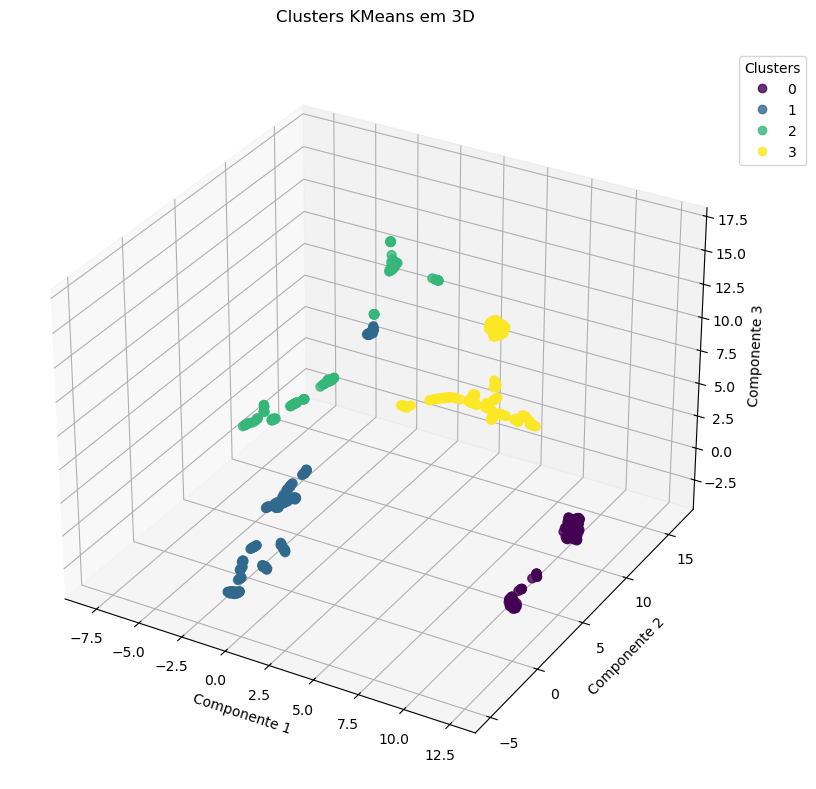

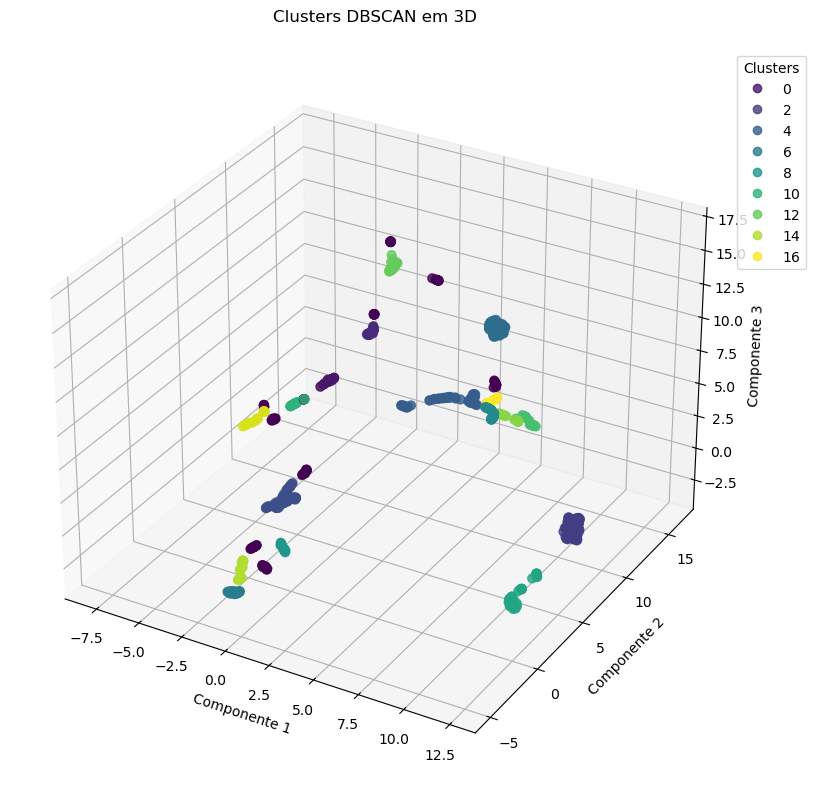

In [94]:
# =============================================
# Gráficos 3D dos clusters
# =============================================
print("\n\n=== VISUALIZAÇÃO 3D DOS CLUSTERS ===")

def plot_3d_clusters(data, clusters, title):
    fig = plt.figure(figsize=(14, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    scatter = ax.scatter(data[:, 0], data[:, 1], data[:, 2], 
                         c=clusters, cmap='viridis', alpha=0.8, s=40)
    
    ax.set_xlabel('Componente 1')
    ax.set_ylabel('Componente 2')
    ax.set_zlabel('Componente 3')
    ax.set_title(title, pad=20)
    
    legend = ax.legend(*scatter.legend_elements(), title="Clusters", bbox_to_anchor=(1.1, 1))
    plt.tight_layout()
    plt.show()

# Redução para 3D
umap_3d = umap.UMAP(n_components=3, random_state=42).fit_transform(Z)

# Plot KMeans
plot_3d_clusters(umap_3d, clusters_kmeans, "Clusters KMeans em 3D")

# Plot DBSCAN
plot_3d_clusters(umap_3d, clusters_dbscan, "Clusters DBSCAN em 3D")


A terceira dimensão, gerada pelo UMAP 3D, oferece uma visão espacial adicional, permitindo uma melhor distinção entre clusters que poderiam parecer sobrepostos ou muito próximos na projeção 2D. Esta visualização confirma ou questiona a separação dos grupos. A disposição dos clusters coloridos e a dispersão dos outliers em cinza (no DBSCAN) no espaço 3D geralmente reforçam as estruturas observadas em 2D, validadas pelas métricas, aumentando a confiança na análise realizada.

In [96]:
# =============================================
# Análise descritiva por cluster
# =============================================
print("\n\n=== ANÁLISE DESCRITIVA POR CLUSTER ===")

def analyze_cluster(clusters, method_name):
    print(f"\nMétodo: {method_name}")
    dataset[f'Cluster_{method_name}'] = clusters
    
    # Estatísticas básicas por cluster
    stats = dataset.groupby(f'Cluster_{method_name}').agg({
        'nome': 'count',
        'lendário': 'sum',
        'geração': lambda x: x.mode()[0],
        'tipo 1': lambda x: x.mode()[0]
    }).rename(columns={
        'nome': 'Total Pokémon',
        'lendário': 'Lendários',
        'geração': 'Geração Mais Comum',
        'tipo 1': 'Tipo Primário Mais Comum'
    })
    
    # Adicionar contagem de tipos primários
    type_counts = dataset.groupby([f'Cluster_{method_name}', 'tipo 1']).size().unstack().fillna(0)
    
    display(stats)
    print("\nDistribuição de Tipos Primários por Cluster:")
    display(type_counts)

# Análise KMeans
analyze_cluster(clusters_kmeans, 'KMeans')

# Análise DBSCAN
analyze_cluster(clusters_dbscan, 'DBSCAN')




=== ANÁLISE DESCRITIVA POR CLUSTER ===

Método: KMeans


,Total Pokémon,Lendários,Geração Mais Comum,Tipo Primário Mais Comum
Cluster_KMeans,,,,
0,116,14,1,Water
1,227,20,5,Bug
2,187,9,1,Grass
3,270,22,3,Normal



Distribuição de Tipos Primários por Cluster:


tipo 1,Bug,Dark,Dragon,Electric,Fairy,Fighting,Fire,Flying,Ghost,Grass,Ground,Ice,Normal,Poison,Psychic,Rock,Steel,Water
Cluster_KMeans,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,38.0,11.0,5.0,62.0
1,46.0,27.0,28.0,40.0,17.0,21.0,46.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,23.0,4.0,4.0,4.0,0.0,5.0,5.0,0.0,24.0,56.0,19.0,5.0,3.0,1.0,0.0,11.0,10.0,13.0
3,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,8.0,14.0,13.0,19.0,95.0,27.0,19.0,22.0,12.0,37.0



Método: DBSCAN


,Total Pokémon,Lendários,Geração Mais Comum,Tipo Primário Mais Comum
Cluster_DBSCAN,,,,
-1,121,6,6,Bug
0,37,0,1,Grass
1,35,3,1,Fire
2,67,4,1,Water
3,64,8,5,Bug
4,69,8,5,Normal
5,61,2,3,Normal
6,30,1,1,Electric
7,54,8,3,Water



Distribuição de Tipos Primários por Cluster:


tipo 1,Bug,Dark,Dragon,Electric,Fairy,Fighting,Fire,Flying,Ghost,Grass,Ground,Ice,Normal,Poison,Psychic,Rock,Steel,Water
Cluster_DBSCAN,,,,,,,,,,,,,,,,,,
-1,27.0,2.0,0.0,0.0,15.0,6.0,18.0,0.0,20.0,0.0,13.0,0.0,0.0,16.0,0.0,4.0,0.0,0.0
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,19.0,6.0,5.0,3.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,33.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,62.0
3,29.0,15.0,9.0,9.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,8.0,14.0,13.0,3.0,24.0,3.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,61.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,7.0,10.0,10.0,5.0,15.0


Estas tabelas complementam as análises anteriores, focando em características não diretamente relacionadas aos stats base: contagem total, número de lendários, geração mais comum e tipo primário mais comum para cada cluster (excluindo os outliers).

Permitem comparar as distribuições entre KMeans e DBSCAN, destacando como cada método organiza os Pokémon por tipo, evidenciando, por exemplo, se o DBSCAN isola certos tipos de forma mais concentrada nos clusters densos.

A adição da geração mais comum oferece uma perspectiva temporal/demográfica adicional, proporcionando uma visão mais completa da distribuição dos Pokémon.

Observando os dados, o KMeans destacou o Cluster 3 como o maior, com 254 Pokémon (31,8%), predominantemente do tipo Inseto. O menor foi o Cluster 0, com 116 Pokémon (14,5%), dominado por Pokémon do tipo Água (62%) e da geração 1. O Cluster 2 chamou atenção pela alta concentração de Pokémon do tipo Erva (56%), enquanto o Cluster 1 apresentou diversidade, com 27% do tipo Psíquico e 22% do tipo Normal.

No DBSCAN, o Cluster 4 foi o maior, com 90 Pokémon (11,3%), predominantemente do tipo Normal (33%) e da geração 5. O cluster de outliers (-1) reuniu 85 Pokémon (10,6%), com destaque para os tipos Inseto (17%) e Fantasma (17%). O Cluster 11 apresentou 22% de Pokémon do tipo Água, enquanto o Cluster 15 foi composto por 38% de Pokémon do tipo Gelo.

Além disso, o Cluster 9 reuniu 49 Pokémon (6,1%), com 61% do tipo Psíquico, o mais dominante em um único grupo. O Cluster 6 foi exclusivamente composto por Pokémon do tipo Elétrico (100%), mostrando uma coesão notável no tipo primário. Essa segmentação revela padrões interessantes entre os tipos e as gerações dos Pokémon.

## **7. Conclusão**

Este estudo teve como objetivo explorar o vasto conjunto de dados dos Pokémon, focando-se na descoberta de arquétipos ou agrupamentos naturais, sem depender de classificações pré-existentes, como tipo ou estatuto lendário. O objetivo foi aplicar técnicas de aprendizagem não supervisionada para identificar estruturas latentes e caracterizar os grupos resultantes, oferecendo uma nova perspectiva sobre a diversidade funcional dentro do universo Pokémon.

O processo começou com a preparação dos dados (Ponto 3), que incluiu limpeza, tratamento de valores ausentes, renomeação de atributos para maior clareza, conversão das variáveis categóricas em numéricas (encoding) e normalização das estatísticas numéricas (min-max scaling), criando uma base homogénea para os algoritmos.

A fase de redução de dimensionalidade (Ponto 4) foi um ponto crítico. A análise com PCA mostrou as limitações de abordagens lineares, que explicaram apenas uma pequena parte da variância e não forneceram visualizações úteis. A aplicação do UMAP, uma técnica não linear, foi o avanço decisivo. O UMAP preservou a estrutura original dos dados, e as visualizações coloridas revelaram tendências claras de agrupamento por Tipo 1, padrões relacionados à Geração e uma concentração de Pokémon Lendários, sugerindo perfis estatísticos distintos para esses grupos. Essa representação UMAP serviu como base para a clusterização subsequente.

Na fase de clusterização (Ponto 5), foram usadas duas abordagens complementares. O KMeans, com k=4, foi escolhido com base no Método do Cotovelo, dividindo os Pokémon em quatro clusters. O DBSCAN, baseado em densidade local, identificou um número semelhante de núcleos densos e também isolou vários outliers, que não se encaixavam nos padrões de densidade dos clusters maiores. Para interpretar esses clusters, foram criados dashboards interativos, que traduziam os resultados numéricos em perfis compreensíveis, utilizando visualizações de radar para estatísticas, gráficos de pizza para composição de tipos, tabelas detalhadas de variação e atribuições de tipologia estratégica, oferecendo uma visão prática dos agrupamentos.

A análise final e a avaliação comparativa (Ponto 6) ajudaram a consolidar a compreensão dos resultados. A investigação dos outliers no DBSCAN confirmou a sua diversidade, com uma notável presença de Pokémon Lendários, que se distanciam dos grupos mais comuns devido à sua singularidade estatística. A avaliação quantitativa, usando o Silhouette Score, mostrou que ambos os métodos produziram segmentações razoáveis, mas com algumas diferenças na coesão e separação dos clusters. As visualizações em 3D ajudaram a confirmar a separação dos clusters. Finalmente, as tabelas de resumo estatístico e descritivo, incluindo a análise da distribuição de tipos por cluster (crosstabs), validaram quantitativamente os perfis identificados e permitiram uma comparação direta das características médias dos clusters obtidos por cada método.

## **8. Bibliografia**

**VanderPlas, J. (2016).** Python Data Science Handbook: Essential Tools for Working with Data. O'Reilly Media.

**Vidal, R., Ma, Y., & Sastry, S. S. (2016).** Generalized Principal Component Analysis. Springer-Verlag New York.

**Hennig, C., Meila, M., Murtagh, F., & Rocci, R. (2016).** Handbook of Cluster Analysis. CRC Press.